# 10 - Model Diagnostics and Error Analysis

## Objective

Notebook này chẩn đoán lỗi của các model trước khi hyperparameter tuning. Mục tiêu là hiểu model mắc lỗi ở đâu và vì sao, không phải retrain hoặc chọn final model.

Diagnostic chính của notebook này là **numeric + LightGBM + target_price**, candidate chính được chốt từ notebook 09. Các cấu hình `LightGBM + log_target_price`, `CatBoost + target_price`, và `CatBoost + log_target_price` vẫn được giữ làm đối chứng để so sánh.

| Diagnostic Area | Key Question |
|---|---|
| Overall error | Candidate chính có ổn định trên original price scale không? |
| Residual distribution | Residuals có centered quanh 0 hay lệch hệ thống? |
| Heteroscedasticity | Residual variance có tăng theo actual price không? |
| Price-segment bias | Low-price bị overpredict? Premium bị underpredict? |
| Log-target compression | Log-transform có nén prediction ở vùng giá cao không? |
| Outliers / data quality | Các lỗi cực đại là hard cases hợp lệ hay nhiễu dữ liệu? |
| Exploratory corrections | Hiệu chỉnh post-hoc đơn giản có giảm error pattern chính không? |

> **Important**: Notebook này không thực hiện hyperparameter tuning. Correction experiments chỉ mang tính exploratory, được ước tính trên test set, và không được report như final model performance.

### Model handling

Notebook tự động phát hiện model-target combinations thực sự có trong prediction dataframe theo pattern `pred_<Model>_<target>`. Các model được request là LightGBM và CatBoost với hai target strategy: `target_price` và `log_target_price`. Model-target pair nào thiếu prediction columns sẽ được skip và ghi rõ trong validation output.

**Artifacts được load từ**: `artifacts/modeling_numeric/` (output của notebook 07b/08b/09)

## 1. Imports và Configuration

In [36]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    median_absolute_error,
    r2_score,
)

try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error
    def root_mean_squared_error(y_true, y_pred):
        return mean_squared_error(y_true, y_pred, squared=False)

try:
    import statsmodels.stats.diagnostic as sm_diag
    HAS_STATSMODELS = True
except ImportError:
    HAS_STATSMODELS = False
    print("statsmodels not available; formal heteroscedasticity tests will be skipped.")

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

In [37]:
# Configuration and paths
REQUESTED_MODELS = ["LightGBM", "CatBoost"]
TARGET_CANDIDATES = ["target_price", "log_target_price"]

PRIMARY_MODEL = "LightGBM"
PRIMARY_TARGET = "target_price"
PRIMARY_FEATURE_REPRESENTATION = "numeric"
FEATURE_MODE = PRIMARY_FEATURE_REPRESENTATION
FEATURE_SET = PRIMARY_FEATURE_REPRESENTATION

RANDOM_STATE = 42
PROJECT_ROOT = Path.cwd().resolve().parents[1]
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "laptop_processed_numeric.csv"

ARTIFACT_DIR    = PROJECT_ROOT / "artifacts" / f"modeling_{PRIMARY_FEATURE_REPRESENTATION}"
METRICS_DIR     = ARTIFACT_DIR / "metrics"
PREDICTIONS_DIR = ARTIFACT_DIR / "predictions"
COMPARISON_DIR  = ARTIFACT_DIR / "target_comparison"
DIAGNOSTICS_DIR = ARTIFACT_DIR / "model_diagnostics"
DIAGNOSTICS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME_FOR_FILE = {"LightGBM": "LightGBM", "CatBoost": "CatBoost"}
output_prefix = f"{PRIMARY_MODEL.lower()}_{PRIMARY_TARGET}_{PRIMARY_FEATURE_REPRESENTATION}"


def safe_filename(model_name: str, target_used: str) -> str:
    base = MODEL_NAME_FOR_FILE.get(model_name, model_name.replace(" ", ""))
    return f"{base}_{target_used}"


def expected_prediction_col(model_name: str, target_used: str) -> str:
    return f"pred_{safe_filename(model_name, target_used)}"


def format_model_target_pairs(pairs):
    return ", ".join(f"{m} + {t}" for m, t in pairs) if pairs else "None"


print(f"PROJECT_ROOT   : {PROJECT_ROOT}")
print(f"DATA_PATH      : {DATA_PATH}")
print(f"FEATURE_SET    : {FEATURE_SET}")
print(f"DIAGNOSTICS_DIR: {DIAGNOSTICS_DIR}")
print(f"Requested models: {REQUESTED_MODELS}")
print(f"Primary diagnostic pair: {PRIMARY_FEATURE_REPRESENTATION} + {PRIMARY_MODEL} + {PRIMARY_TARGET}")

PROJECT_ROOT   : Y:\Python\Laptop-Price-Prediction
DATA_PATH      : Y:\Python\Laptop-Price-Prediction\data\processed\laptop_processed_numeric.csv
FEATURE_SET    : numeric
DIAGNOSTICS_DIR: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\model_diagnostics
Requested models: ['LightGBM', 'CatBoost']
Primary diagnostic pair: numeric + LightGBM + target_price


## 2. Load Predictions, Metrics và Original Data

Load artifacts đã được lưu bởi notebook 07b. Không có model retraining ở bước này.

In [38]:
# ── Kiểm tra file có sẵn ─────────────────────────────────────────────────────
print('=== Metrics files ===')
for f in sorted(METRICS_DIR.glob('*.csv')):
    print(f'  {f.name}')

print()
print('=== Predictions files ===')
for f in sorted(PREDICTIONS_DIR.glob('*.csv')):
    print(f'  {f.name}')

=== Metrics files ===
  log_scale_model_metrics.csv
  model_metrics.csv

=== Predictions files ===
  test_predictions.csv


In [39]:
# Load metrics
metrics_df = None
metrics_path = None
for candidate in ["model_metrics.csv", "metrics_df.csv", "all_metrics.csv"]:
    p = METRICS_DIR / candidate
    if p.exists():
        metrics_df = pd.read_csv(p)
        metrics_path = p
        print(f"Loaded metrics: {candidate}  shape={metrics_df.shape}")
        break

if metrics_df is None:
    raise FileNotFoundError("No metrics CSV found. Run notebook 07b first.")

metrics_df.columns = [c.strip().lower().replace(" ", "_").replace("-", "_") for c in metrics_df.columns]
metrics_df.rename(columns={"median_ae": "median_absolute_error", "train_time_sec": "training_time_seconds"}, inplace=True)
if "mape" in metrics_df.columns and metrics_df["mape"].max() > 10:
    metrics_df["mape"] = metrics_df["mape"] / 100.0

display(metrics_df.head(10))


Loaded metrics: model_metrics.csv  shape=(16, 12)


,model_name,model_type,target_used,evaluation_scale,mae,rmse,r2,mape,median_absolute_error,max_error,training_time_seconds,predict_time_sec
0,LightGBM,gradient_boosting,target_price,target_price,3.2246,5.3365,0.8930,0.2734,1.8200,33.8460,0.6659,0.0078
1,CatBoost,gradient_boosting,target_price,target_price,3.3104,5.4136,0.8898,0.2912,1.9472,40.7371,1.1658,0.0037
2,LightGBM,gradient_boosting,log_target_price,target_price,3.2178,5.5069,0.8860,0.2517,1.7537,43.1585,0.3645,0.0132
3,Random Forest,tree_ensemble,target_price,target_price,3.3197,5.5824,0.8829,0.2903,1.8316,45.1167,1.4286,0.1108
4,CatBoost,gradient_boosting,log_target_price,target_price,3.3062,5.7275,0.8767,0.2544,1.7231,40.0861,1.3581,0.0029
5,Random Forest,tree_ensemble,log_target_price,target_price,3.3611,5.7696,0.8749,0.2704,1.8100,49.2344,1.4979,0.1033
6,Extra Trees,tree_ensemble,target_price,target_price,3.4130,5.8066,0.8733,0.2963,1.9701,62.1980,1.7264,0.0737
7,Extra Trees,tree_ensemble,log_target_price,target_price,3.3826,5.8887,0.8697,0.2804,1.8000,61.1935,1.7242,0.0938
8,Ridge,linear,target_price,target_price,4.2948,6.8808,0.8220,0.3922,2.5040,56.9995,0.0264,0.0034
9,Lasso,linear,target_price,target_price,4.2943,6.8819,0.8220,0.3920,2.5057,57.0195,0.4701,0.0020


In [40]:
# Load test predictions
predictions_raw = None
predictions_path = None
for candidate in ["test_predictions.csv", "predictions_df.csv", "all_predictions.csv"]:
    p = PREDICTIONS_DIR / candidate
    if p.exists():
        predictions_raw = pd.read_csv(p)
        predictions_path = p
        print(f"Loaded predictions: {candidate}  shape={predictions_raw.shape}")
        break

if predictions_raw is None:
    for f in sorted(PREDICTIONS_DIR.glob("*.csv")):
        try:
            df_try = pd.read_csv(f)
            if any("pred" in c.lower() for c in df_try.columns):
                predictions_raw = df_try
                predictions_path = f
                print(f"Fallback predictions: {f.name}  shape={predictions_raw.shape}")
                break
        except Exception:
            continue

if predictions_raw is None:
    raise FileNotFoundError("No predictions CSV found. Run notebook 07b first.")

display(predictions_raw.head())
print("Columns:", predictions_raw.columns.tolist())


Loaded predictions: test_predictions.csv  shape=(1460, 18)


,sample_id,y_true_price,pred_LinearRegression_target_price,pred_LinearRegression_log_target_price,pred_Ridge_target_price,pred_Ridge_log_target_price,pred_Lasso_target_price,pred_Lasso_log_target_price,pred_ElasticNet_target_price,pred_ElasticNet_log_target_price,pred_RandomForest_target_price,pred_RandomForest_log_target_price,pred_ExtraTrees_target_price,pred_ExtraTrees_log_target_price,pred_LightGBM_target_price,pred_LightGBM_log_target_price,pred_CatBoost_target_price,pred_CatBoost_log_target_price
0,3909,5.5000,4.8707,5.0810,5.0816,4.9399,5.0704,5.0358,5.0665,4.9897,4.6633,4.1106,4.7393,5.1778,3.7060,3.5681,4.3277,3.8327
1,6004,37.4990,22.5133,20.9212,22.7142,20.9117,22.6888,20.7552,22.6843,20.8199,30.9067,28.9058,32.4439,31.6378,28.5706,30.3664,27.9014,28.0176
2,1768,27.4900,15.5426,13.1802,15.4753,13.0721,15.4822,12.8115,15.4787,12.9277,21.3259,19.5354,21.2413,19.3984,19.6340,18.2145,17.3898,16.6207
3,3360,7.8000,6.8942,6.4143,6.6530,6.1988,6.6555,6.1620,6.6491,6.1789,8.7528,8.4264,10.0000,10.0000,8.0080,8.0429,7.4755,7.5056
4,4700,12.9900,10.3932,7.6820,10.2927,7.6271,10.2967,7.7830,10.3003,7.7143,11.5081,11.4461,11.6000,11.5964,11.1778,10.9470,10.8644,11.0274


Columns: ['sample_id', 'y_true_price', 'pred_LinearRegression_target_price', 'pred_LinearRegression_log_target_price', 'pred_Ridge_target_price', 'pred_Ridge_log_target_price', 'pred_Lasso_target_price', 'pred_Lasso_log_target_price', 'pred_ElasticNet_target_price', 'pred_ElasticNet_log_target_price', 'pred_RandomForest_target_price', 'pred_RandomForest_log_target_price', 'pred_ExtraTrees_target_price', 'pred_ExtraTrees_log_target_price', 'pred_LightGBM_target_price', 'pred_LightGBM_log_target_price', 'pred_CatBoost_target_price', 'pred_CatBoost_log_target_price']


In [41]:
# Load original data (numeric feature representation only)
if PRIMARY_FEATURE_REPRESENTATION != "numeric":
    raise ValueError("Notebook 10 primary diagnostics must use the numeric feature representation.")

if "numeric" not in DATA_PATH.name.lower():
    raise ValueError(f"Expected numeric processed data, got: {DATA_PATH}")

df_orig = pd.read_csv(DATA_PATH)
TARGET_COLUMNS = ['target_price', 'log_target_price']
feature_cols = [c for c in df_orig.columns if c not in TARGET_COLUMNS]

print(f'Original data shape: {df_orig.shape}')
print(f'Feature representation: {PRIMARY_FEATURE_REPRESENTATION}')
print(f'Feature columns ({len(feature_cols)}): {feature_cols[:10]} ...')

# Numeric-only dataset from notebook 07b/08b/09.
NUMERIC_FEATURE_COLS = df_orig[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
print(f'Numeric feature columns: {len(NUMERIC_FEATURE_COLS)}')

Original data shape: (7296, 88)
Feature representation: numeric
Feature columns (86): ['ram_gb', 'storage_gb', 'screen_size_inch', 'brand_is_rare', 'model_is_rare', 'ram_missing', 'storage_missing', 'screen_missing', 'no_info_brand', 'no_info_model'] ...
Numeric feature columns: 86


In [42]:
# Merge numeric features into predictions for feature-level inspection
merge_ok = False
merge_duplicate_count = 0

if "sample_id" in predictions_raw.columns:
    try:
        feature_lookup = df_orig[feature_cols].reset_index().rename(columns={"index": "sample_id"})
        predictions_with_features = predictions_raw.merge(feature_lookup, on="sample_id", how="left", validate="many_to_one")
        merge_duplicate_count = int(predictions_with_features.duplicated().sum())
        merge_ok = predictions_with_features[feature_cols[0]].notna().mean() > 0.9 if feature_cols else False
        if merge_ok:
            print(f"Feature merge successful. Shape: {predictions_with_features.shape}")
    except Exception as e:
        print(f"Feature merge failed: {e}")

if not merge_ok:
    predictions_with_features = predictions_raw.copy()
    merge_duplicate_count = int(predictions_with_features.duplicated().sum())
    print("Feature-level diagnostics will use prediction columns only; named feature merge was not reliable.")


Feature merge successful. Shape: (1460, 104)


## 3. Validation and Available Model Detection

This section validates required inputs, verifies prediction column naming, checks merge integrity, and detects which requested model-target combinations are actually analyzable.


In [43]:
import re

PRED_COL_PATTERN = re.compile(r"^pred_(?P<model>.+)_(?P<target>log_target_price|target_price)$")
validation_rows = []

def record_check(check, status, detail=""):
    validation_rows.append({"Check": check, "Status": status, "Detail": detail})
    icon = "OK" if status == "PASS" else "WARN" if status == "WARN" else "FAIL"
    print(f"[{icon}] {check}: {detail}")

def require_columns(df, cols, name):
    missing = [c for c in cols if c not in df.columns]
    record_check(f"{name} required columns", "PASS" if not missing else "FAIL", "all present" if not missing else f"missing={missing}")
    return missing

for label, p in {"Metrics file": metrics_path, "Predictions file": predictions_path, "Original numeric dataset": DATA_PATH}.items():
    record_check(label, "PASS" if p and p.exists() else "FAIL", str(p))

require_columns(metrics_df, ["model_name", "target_used", "mae", "rmse", "mape"], "metrics_df")
actual_candidates = ["y_true_price", "actual_price", "target_price"]
actual_col = next((c for c in actual_candidates if c in predictions_raw.columns), None)
if actual_col is None:
    record_check("Actual target column", "FAIL", f"expected one of {actual_candidates}")
    raise ValueError("Cannot find actual price column in predictions. Check predictions CSV.")
record_check("Actual target column", "PASS", actual_col)
require_columns(df_orig, ["target_price", "log_target_price"], "df_orig")

prediction_cols = [c for c in predictions_raw.columns if c.startswith("pred_")]
pattern_mismatches = [c for c in prediction_cols if PRED_COL_PATTERN.match(c) is None]
record_check("Prediction column naming pattern", "PASS" if not pattern_mismatches else "WARN", "all prediction columns match" if not pattern_mismatches else f"non-matching columns={pattern_mismatches}")

available_model_targets = []
skipped_model_targets = []
for model_name in REQUESTED_MODELS:
    for target_used in TARGET_CANDIDATES:
        col = expected_prediction_col(model_name, target_used)
        if col in predictions_raw.columns:
            available_model_targets.append((model_name, target_used))
        else:
            skipped_model_targets.append((model_name, target_used, col))

SELECTED_MODELS = [m for m in REQUESTED_MODELS if any(pair[0] == m for pair in available_model_targets)]
ANALYZED_TARGETS = [t for t in TARGET_CANDIDATES if any(pair[1] == t for pair in available_model_targets)]
record_check("Available requested model-target combinations", "PASS" if available_model_targets else "FAIL", format_model_target_pairs(available_model_targets))
if not available_model_targets:
    raise ValueError("No requested model-target prediction columns are available for diagnostics.")

for model_name in REQUESTED_MODELS:
    missing_for_model = [t for m, t, _ in skipped_model_targets if m == model_name]
    if missing_for_model and model_name not in SELECTED_MODELS:
        record_check(f"{model_name} availability", "WARN", "skipped because prediction columns were unavailable")
    elif missing_for_model:
        record_check(f"{model_name} partial availability", "WARN", f"missing targets={missing_for_model}")

record_check("Duplicated rows after feature merge", "PASS" if merge_duplicate_count == 0 else "WARN", f"duplicate rows={merge_duplicate_count}")
key_cols = [actual_col] + [expected_prediction_col(m, t) for m, t in available_model_targets]
missing_report = predictions_raw[key_cols].isna().sum().loc[lambda s: s > 0]
record_check("Missing values in key columns", "PASS" if missing_report.empty else "WARN", "none" if missing_report.empty else missing_report.to_dict())

non_positive_actual = int((predictions_raw[actual_col] <= 0).sum())
record_check("Actual target values positive", "PASS" if non_positive_actual == 0 else "FAIL", f"non-positive rows={non_positive_actual}")
non_positive_pred = {col: int((predictions_raw[col] <= 0).sum()) for col in key_cols[1:] if int((predictions_raw[col] <= 0).sum()) > 0}
record_check("Predicted values positive", "PASS" if not non_positive_pred else "WARN", "all positive" if not non_positive_pred else str(non_positive_pred))
if non_positive_actual:
    raise ValueError("Actual prices must be positive for percentage and ratio diagnostics.")
if non_positive_pred:
    print("Warning: non-positive predictions are retained for diagnostics and flagged as data/model quality issues.")

validation_df = pd.DataFrame(validation_rows)
validation_df.to_csv(DIAGNOSTICS_DIR / "validation_checks.csv", index=False)
print("\nAnalyzed models:", SELECTED_MODELS)
print("Analyzed model-target pairs:", available_model_targets)
print("Saved: validation_checks.csv")
display(validation_df)


[OK] Metrics file: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\metrics\model_metrics.csv
[OK] Predictions file: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\predictions\test_predictions.csv
[OK] Original numeric dataset: Y:\Python\Laptop-Price-Prediction\data\processed\laptop_processed_numeric.csv
[OK] metrics_df required columns: all present
[OK] Actual target column: y_true_price
[OK] df_orig required columns: all present
[OK] Prediction column naming pattern: all prediction columns match
[OK] Available requested model-target combinations: LightGBM + target_price, LightGBM + log_target_price, CatBoost + target_price, CatBoost + log_target_price
[OK] Duplicated rows after feature merge: duplicate rows=0
[OK] Missing values in key columns: none
[OK] Actual target values positive: non-positive rows=0
[WARN] Predicted values positive: {'pred_LightGBM_target_price': 1}

Analyzed models: ['LightGBM', 'CatBoost']
Analyzed model-target pairs: [('LightGBM', 't

,Check,Status,Detail
0,Metrics file,PASS,Y:\Python\Laptop-Price-Prediction\artifacts\mo...
1,Predictions file,PASS,Y:\Python\Laptop-Price-Prediction\artifacts\mo...
2,Original numeric dataset,PASS,Y:\Python\Laptop-Price-Prediction\data\process...
3,metrics_df required columns,PASS,all present
4,Actual target column,PASS,y_true_price
5,df_orig required columns,PASS,all present
6,Prediction column naming pattern,PASS,all prediction columns match
7,Available requested model-target combinations,PASS,"LightGBM + target_price, LightGBM + log_target..."
8,Duplicated rows after feature merge,PASS,duplicate rows=0
9,Missing values in key columns,PASS,none


## 4. Build Diagnostic Error Dataset

Reshape predictions từ wide format sang long format (một dòng mỗi sample x available model-target combination). Missing prediction columns are reported in validation and skipped.


In [44]:
# Build long-format diagnostic dataframe from available prediction columns
print(f"Actual price column: {actual_col}")

def compute_error_columns(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    residual = actual - predicted
    abs_error = np.abs(residual)
    return {
        "residual": residual,
        "absolute_error": abs_error,
        "squared_error": residual ** 2,
        "percentage_error": residual / (actual + 1e-9),
        "absolute_percentage_error": abs_error / (actual + 1e-9),
        "prediction_ratio": predicted / (actual + 1e-9),
    }

diag_frames = []
sample_id = predictions_raw["sample_id"].values if "sample_id" in predictions_raw.columns else np.arange(len(predictions_raw))
actual_values = predictions_raw[actual_col].astype(float).values

for model_name, target_used in available_model_targets:
    col = expected_prediction_col(model_name, target_used)
    predicted_values = predictions_raw[col].astype(float).values
    err = compute_error_columns(actual_values, predicted_values)
    diag_frames.append(pd.DataFrame({
        "sample_id": sample_id,
        "actual_price": actual_values,
        "predicted_price": predicted_values,
        "model_name": model_name,
        "target_used": target_used,
        **err,
    }))

diag_df = pd.concat(diag_frames, ignore_index=True)
print(f"Diagnostic dataframe shape: {diag_df.shape}")
print(f"Models included: {format_model_target_pairs(available_model_targets)}")


Actual price column: y_true_price
Diagnostic dataframe shape: (5840, 11)
Models included: LightGBM + target_price, LightGBM + log_target_price, CatBoost + target_price, CatBoost + log_target_price


In [45]:
# Add price segments
q25, q50, q75 = np.quantile(predictions_raw[actual_col].values, [0.25, 0.50, 0.75])
print(f"Price quantiles: Q25={q25:,.0f}  Q50={q50:,.0f}  Q75={q75:,.0f}")


def assign_segment(price):
    if price <= q25:
        return "Low"
    if price <= q50:
        return "Mid"
    if price <= q75:
        return "High"
    return "Premium"


diag_df["price_segment"] = diag_df["actual_price"].apply(assign_segment)
diag_df["price_segment"] = pd.Categorical(diag_df["price_segment"], categories=["Low", "Mid", "High", "Premium"], ordered=True)

primary_pair = (PRIMARY_MODEL, PRIMARY_TARGET)
if primary_pair not in available_model_targets:
    raise ValueError(
        f"Primary diagnostic pair {PRIMARY_MODEL} + {PRIMARY_TARGET} is unavailable. "
        f"Available pairs: {format_model_target_pairs(available_model_targets)}"
    )

print(f"Primary diagnostic pair: {PRIMARY_FEATURE_REPRESENTATION} + {PRIMARY_MODEL} + {PRIMARY_TARGET}")
main_mask = (diag_df["model_name"] == PRIMARY_MODEL) & (diag_df["target_used"] == PRIMARY_TARGET)
primary_error_df = diag_df[main_mask].copy()
print(primary_error_df["price_segment"].value_counts().sort_index())

diag_df.to_csv(DIAGNOSTICS_DIR / "diagnostic_errors_long.csv", index=False)
primary_error_df.to_csv(DIAGNOSTICS_DIR / f"{output_prefix}_error_cases.csv", index=False)
print("\nSaved: diagnostic_errors_long.csv")
print(f"Saved: {output_prefix}_error_cases.csv")

Price quantiles: Q25=6  Q50=10  Q75=19
Primary diagnostic pair: numeric + LightGBM + target_price
price_segment
Low        366
Mid        364
High       365
Premium    365
Name: count, dtype: int64

Saved: diagnostic_errors_long.csv
Saved: lightgbm_target_price_numeric_error_cases.csv


## 4. Overall Error Diagnostics

Tóm tắt các thống kê error chính cho từng model variant. Ngoài MAE, RMSE, MAPE, còn track thêm:

- **Mean / median residual**: prediction có centered quanh 0 không, hay có systematic bias?
- **Underprediction rate**: tỷ lệ cases mà `actual > predicted`
- **Severe error rate**: tỷ lệ với absolute percentage error > 50%
- **Extreme error rate**: tỷ lệ với absolute percentage error > 100%

In [46]:
def compute_error_metrics(actual, predicted, residual=None, ape=None):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    residual = actual - predicted if residual is None else np.asarray(residual, dtype=float)
    ape = np.abs(residual) / (actual + 1e-9) if ape is None else np.asarray(ape, dtype=float)
    return {
        "n": len(actual),
        "mae": mean_absolute_error(actual, predicted),
        "rmse": root_mean_squared_error(actual, predicted),
        "r2": r2_score(actual, predicted),
        "mape": mean_absolute_percentage_error(actual, predicted),
        "median_absolute_error": median_absolute_error(actual, predicted),
        "mean_residual": residual.mean(),
        "median_residual": np.median(residual),
        "residual_std": residual.std(),
        "underprediction_rate": (residual > 0).mean(),
        "overprediction_rate": (residual < 0).mean(),
        "severe_error_rate": (ape > 0.50).mean(),
        "extreme_error_rate": (ape > 1.00).mean(),
    }


summary_rows = []
for (model_name, target_used), grp in diag_df.groupby(["model_name", "target_used"], observed=True):
    metrics = compute_error_metrics(grp["actual_price"], grp["predicted_price"], grp["residual"], grp["absolute_percentage_error"])
    summary_rows.append({"model_name": model_name, "target_used": target_used, "evaluation_scale": "target_price", **metrics})

summary_df = pd.DataFrame(summary_rows).sort_values("rmse").reset_index(drop=True)
summary_df.to_csv(DIAGNOSTICS_DIR / "diagnostic_model_error_summary.csv", index=False)
print(f"=== Overall Error Summary ({format_model_target_pairs(available_model_targets)}) ===")
display(summary_df)

strong_candidates = summary_df[
    summary_df["model_name"].isin(["LightGBM", "CatBoost"])
    & summary_df["target_used"].isin(["target_price", "log_target_price"])
    & summary_df["evaluation_scale"].eq("target_price")
].copy()
strong_candidates = strong_candidates.sort_values(["mae", "rmse", "r2"], ascending=[True, True, False])
strong_candidates.to_csv(DIAGNOSTICS_DIR / "strong_candidate_comparison.csv", index=False)
print("=== Strong Candidate Comparison (sorted by MAE, RMSE, R2) ===")
display(strong_candidates)

primary_candidate = strong_candidates[
    (strong_candidates["model_name"] == PRIMARY_MODEL)
    & (strong_candidates["target_used"] == PRIMARY_TARGET)
].copy()
if primary_candidate.empty:
    raise ValueError(f"Primary candidate {PRIMARY_MODEL} + {PRIMARY_TARGET} missing from strong candidate comparison.")
print("=== Primary Diagnostic Candidate ===")
display(primary_candidate)

=== Overall Error Summary (LightGBM + target_price, LightGBM + log_target_price, CatBoost + target_price, CatBoost + log_target_price) ===


,model_name,target_used,evaluation_scale,n,mae,rmse,r2,mape,median_absolute_error,mean_residual,median_residual,residual_std,underprediction_rate,overprediction_rate,severe_error_rate,extreme_error_rate
0,LightGBM,target_price,target_price,1460,3.2246,5.3365,0.8930,0.2734,1.8200,0.2960,-0.1651,5.3282,0.4781,0.5219,0.1274,0.0336
1,CatBoost,target_price,target_price,1460,3.3104,5.4136,0.8898,0.2912,1.9472,0.3814,-0.1615,5.4002,0.4760,0.5240,0.1445,0.0363
2,LightGBM,log_target_price,target_price,1460,3.2178,5.5069,0.8860,0.2517,1.7537,0.7587,0.1525,5.4543,0.5274,0.4726,0.1034,0.0199
3,CatBoost,log_target_price,target_price,1460,3.3062,5.7275,0.8767,0.2544,1.7231,1.0399,0.1977,5.6323,0.5390,0.4610,0.1123,0.0192


=== Strong Candidate Comparison (sorted by MAE, RMSE, R2) ===


,model_name,target_used,evaluation_scale,n,mae,rmse,r2,mape,median_absolute_error,mean_residual,median_residual,residual_std,underprediction_rate,overprediction_rate,severe_error_rate,extreme_error_rate
2,LightGBM,log_target_price,target_price,1460,3.2178,5.5069,0.8860,0.2517,1.7537,0.7587,0.1525,5.4543,0.5274,0.4726,0.1034,0.0199
0,LightGBM,target_price,target_price,1460,3.2246,5.3365,0.8930,0.2734,1.8200,0.2960,-0.1651,5.3282,0.4781,0.5219,0.1274,0.0336
3,CatBoost,log_target_price,target_price,1460,3.3062,5.7275,0.8767,0.2544,1.7231,1.0399,0.1977,5.6323,0.5390,0.4610,0.1123,0.0192
1,CatBoost,target_price,target_price,1460,3.3104,5.4136,0.8898,0.2912,1.9472,0.3814,-0.1615,5.4002,0.4760,0.5240,0.1445,0.0363


=== Primary Diagnostic Candidate ===


,model_name,target_used,evaluation_scale,n,mae,rmse,r2,mape,median_absolute_error,mean_residual,median_residual,residual_std,underprediction_rate,overprediction_rate,severe_error_rate,extreme_error_rate
0,LightGBM,target_price,target_price,1460,3.2246,5.3365,0.8930,0.2734,1.8200,0.2960,-0.1651,5.3282,0.4781,0.5219,0.1274,0.0336


In [47]:
# Interpretation for each available model-target pair
for _, row in summary_df.iterrows():
    print(f"=== {row['model_name']} + {row['target_used']} ===")
    print(f"  MAE={row['mae']:,.2f}  RMSE={row['rmse']:,.2f}  MAPE={row['mape']:.1%}")
    print(f"  Mean residual   : {row['mean_residual']:,.0f}")
    print(f"  Median residual : {row['median_residual']:,.0f}")
    mr = row["mean_residual"]
    if abs(mr) < 1e5:
        print("  Residuals are roughly centered around zero.")
    elif mr > 0:
        print("  Positive mean residual: model tends to underpredict.")
    else:
        print("  Negative mean residual: model tends to overpredict.")
    print(f"  Underprediction rate: {row['underprediction_rate']:.1%}")
    print(f"  Severe error rate (APE>50%): {row['severe_error_rate']:.1%}")
    print(f"  Extreme error rate (APE>100%): {row['extreme_error_rate']:.1%}")
    print()


=== LightGBM + target_price ===
  MAE=3.22  RMSE=5.34  MAPE=27.3%
  Mean residual   : 0
  Median residual : -0
  Residuals are roughly centered around zero.
  Underprediction rate: 47.8%
  Severe error rate (APE>50%): 12.7%
  Extreme error rate (APE>100%): 3.4%

=== CatBoost + target_price ===
  MAE=3.31  RMSE=5.41  MAPE=29.1%
  Mean residual   : 0
  Median residual : -0
  Residuals are roughly centered around zero.
  Underprediction rate: 47.6%
  Severe error rate (APE>50%): 14.5%
  Extreme error rate (APE>100%): 3.6%

=== LightGBM + log_target_price ===
  MAE=3.22  RMSE=5.51  MAPE=25.2%
  Mean residual   : 1
  Median residual : 0
  Residuals are roughly centered around zero.
  Underprediction rate: 52.7%
  Severe error rate (APE>50%): 10.3%
  Extreme error rate (APE>100%): 2.0%

=== CatBoost + log_target_price ===
  MAE=3.31  RMSE=5.73  MAPE=25.4%
  Mean residual   : 1
  Median residual : 0
  Residuals are roughly centered around zero.
  Underprediction rate: 53.9%
  Severe error rat

### Interpretation - Overall Model Performance

All four strong candidate configurations are retained for comparison: `LightGBM + target_price`, `LightGBM + log_target_price`, `CatBoost + target_price`, and `CatBoost + log_target_price`.

`LightGBM + target_price` is selected as the primary diagnostic pair because it is the most balanced candidate on the real-price scale. MAE remains close to the best alternative, while the raw target setup avoids the high-price compression pattern that appears in log-target diagnostics and gives a more direct reading of error in million VND.

MAE is important because it tells us how many million VND the model is wrong by on average. However, when the MAE gap between `LightGBM + log_target_price` and `LightGBM + target_price` is small, notebook 10 prioritizes `LightGBM + target_price` because the target is trained directly on the final business scale and supports clearer RMSE, R2, and residual interpretation.

`CatBoost` and configurations using `log_target_price` remain useful secondary candidates for post-tuning comparison, but they are not the main diagnostic direction in this notebook.

## 5. Heteroscedasticity Diagnosis

**Heteroscedasticity** nghĩa là residual variance không đồng đều theo dải giá. Nếu error tăng khi actual price tăng, model kém tin cậy hơn ở vùng giá cao.

> Với tree-based models, heteroscedasticity không invalidate model, nhưng ảnh hưởng đến cách diễn giải RMSE và gợi ý nên dùng segment-aware evaluation hoặc sample weighting khi tuning.

Chẩn đoán qua:
1. Scatter plot residuals vs actual price
2. Binned residual variance table
3. Spearman correlation tests

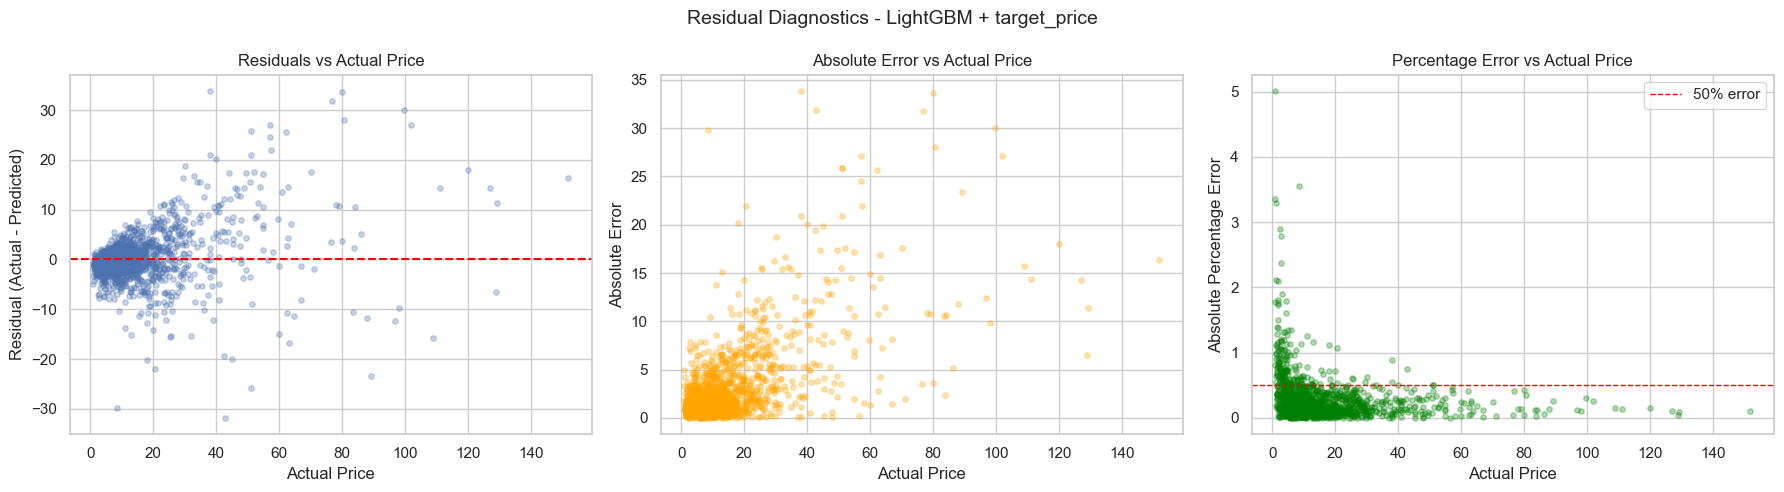

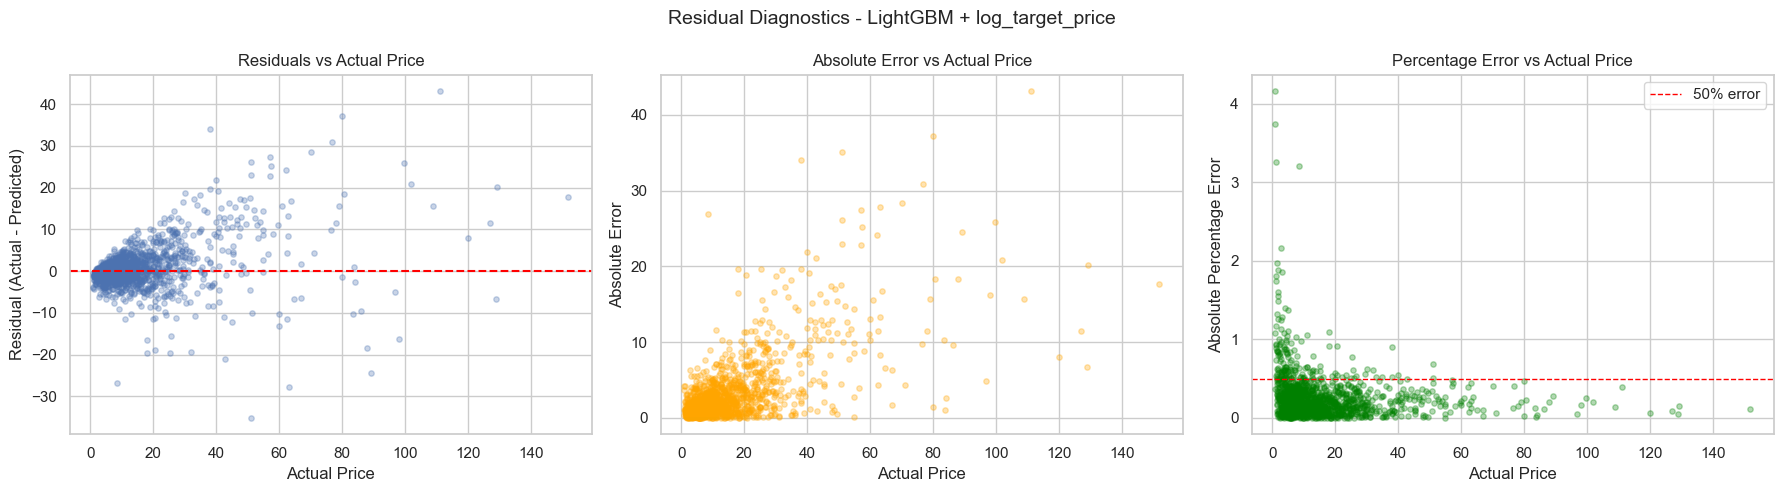

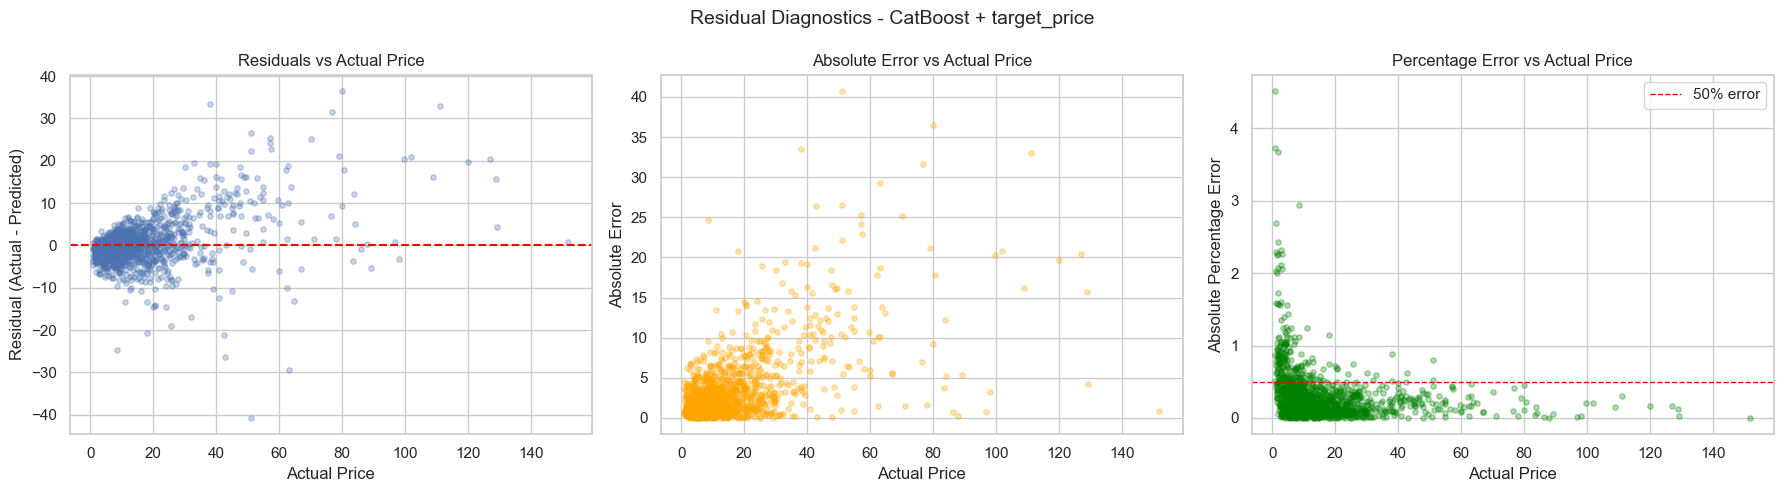

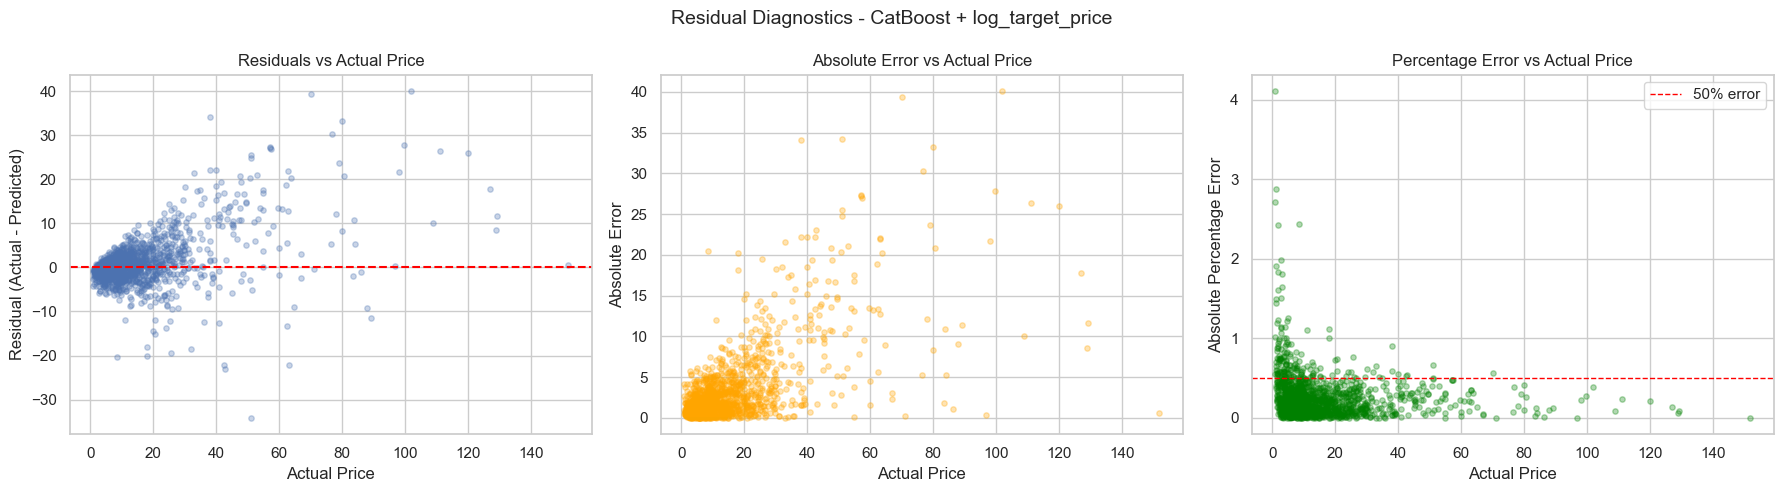

In [48]:
def plot_heteroscedasticity(diag_df, model_name, target_used, save_dir):
    """Three residual scatter plots for one model variant."""
    mask  = (diag_df['model_name'] == model_name) & (diag_df['target_used'] == target_used)
    grp   = diag_df[mask]
    label = f'{model_name} + {target_used}'
    fn    = safe_filename(model_name, target_used)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Residual Diagnostics - {label}', fontsize=14)

    axes[0].scatter(grp['actual_price'], grp['residual'], alpha=0.3, s=15)
    axes[0].axhline(0, color='red', linewidth=1.5, linestyle='--')
    axes[0].set_xlabel('Actual Price')
    axes[0].set_ylabel('Residual (Actual - Predicted)')
    axes[0].set_title('Residuals vs Actual Price')

    axes[1].scatter(grp['actual_price'], grp['absolute_error'], alpha=0.3, s=15, color='orange')
    axes[1].set_xlabel('Actual Price')
    axes[1].set_ylabel('Absolute Error')
    axes[1].set_title('Absolute Error vs Actual Price')

    axes[2].scatter(grp['actual_price'], grp['absolute_percentage_error'], alpha=0.3, s=15, color='green')
    axes[2].axhline(0.5, color='red', linewidth=1, linestyle='--', label='50% error')
    axes[2].set_xlabel('Actual Price')
    axes[2].set_ylabel('Absolute Percentage Error')
    axes[2].set_title('Percentage Error vs Actual Price')
    axes[2].legend()

    plt.tight_layout()
    plt.savefig(save_dir / f'heteroscedasticity_{fn}.png', dpi=150, bbox_inches='tight')
    plt.show()


for model_name, target_used in available_model_targets:
    plot_heteroscedasticity(diag_df, model_name, target_used, DIAGNOSTICS_DIR)

### Interpretation - Residual Diagnostics

Across all evaluated model-target combinations, residuals are generally centered around zero, which supports the earlier finding that there is no strong global directional bias. However, the residual spread increases as actual price increases. This indicates heteroscedasticity: the models are less stable for higher-price listings than for lower-price listings.

The absolute error plots show that larger absolute errors mostly occur in the mid-to-high and premium price ranges. This means global metrics such as MAE and RMSE may hide important segment-level weaknesses, especially for expensive listings.

The percentage error plots show many extreme relative errors among very low-price listings. This is expected because small actual prices make percentage errors unstable: even a small absolute error can become a very large percentage error. Therefore, MAPE should be interpreted carefully and should not be the only criterion for model selection.

Overall, these diagnostics suggest two main issues:
1. High-price listings require better calibration because absolute errors become larger.
2. Low-price listings require careful interpretation because percentage errors can look extreme even when absolute errors are small.

For the next tuning notebook, model selection should combine global metrics with segment-level metrics, especially Premium-segment RMSE/underprediction and Low-price MAPE/extreme-error rate.

In [49]:
# Binned residual variance table
het_rows = []
for (model_name, target_used), grp in diag_df.groupby(["model_name", "target_used"], observed=True):
    grp = grp.copy()
    grp["price_bin"] = pd.qcut(grp["actual_price"], q=10, duplicates="drop")
    for bin_label, bin_grp in grp.groupby("price_bin", observed=True):
        metrics = compute_error_metrics(bin_grp["actual_price"], bin_grp["predicted_price"], bin_grp["residual"])
        het_rows.append({
            "model_name": model_name,
            "target_used": target_used,
            "price_bin": str(bin_label),
            "price_min": bin_grp["actual_price"].min(),
            "price_max": bin_grp["actual_price"].max(),
            "count": len(bin_grp),
            "residual_std": bin_grp["residual"].std(),
            "absolute_error_mean": bin_grp["absolute_error"].mean(),
            "rmse": metrics["rmse"],
            "mape": metrics["mape"],
        })
het_df = pd.DataFrame(het_rows)
het_df.to_csv(DIAGNOSTICS_DIR / "heteroscedasticity_binned_error_summary.csv", index=False)

for model_name in SELECTED_MODELS:
    if (model_name, PRIMARY_TARGET) not in available_model_targets:
        continue
    print(f"=== Binned Residual Variance - {model_name} + {PRIMARY_TARGET} ===")
    display(het_df[(het_df["model_name"] == model_name) & (het_df["target_used"] == PRIMARY_TARGET)][["price_bin", "price_min", "price_max", "count", "residual_std", "absolute_error_mean", "rmse", "mape"]])
    print()


=== Binned Residual Variance - LightGBM + target_price ===


,price_bin,price_min,price_max,count,residual_std,absolute_error_mean,rmse,mape
30,"(0.999, 3.5]",1.0000,3.5000,149,1.5483,1.3985,1.9345,0.6779
31,"(3.5, 5.0]",3.5500,5.0000,155,1.8565,1.6093,2.1607,0.3768
32,"(5.0, 6.5]",5.1000,6.5000,143,1.6996,1.2127,1.7466,0.2090
33,"(6.5, 8.1]",6.6000,8.1000,138,2.1416,1.6566,2.1512,0.2240
34,"(8.1, 10.15]",8.2000,10.0990,145,3.6238,2.2498,3.6377,0.2483
35,"(10.15, 12.99]",10.2000,12.9900,150,3.3315,2.4433,3.3206,0.2105
36,"(12.99, 16.5]",13.0000,16.5000,150,3.3346,2.5538,3.3240,0.1736
37,"(16.5, 21.999]",16.7000,21.9990,138,5.1888,3.7990,5.1974,0.1974
38,"(21.999, 31.49]",22.0000,31.4900,147,6.1024,5.1499,6.3686,0.1979
39,"(31.49, 151.89]",31.5000,151.8900,145,11.9890,10.2825,12.9460,0.1998



=== Binned Residual Variance - CatBoost + target_price ===


,price_bin,price_min,price_max,count,residual_std,absolute_error_mean,rmse,mape
10,"(0.999, 3.5]",1.0000,3.5000,149,1.6126,1.5253,2.0503,0.7425
11,"(3.5, 5.0]",3.5500,5.0000,155,1.8600,1.6225,2.2367,0.3824
12,"(5.0, 6.5]",5.1000,6.5000,143,1.8975,1.4310,1.9498,0.2455
13,"(6.5, 8.1]",6.6000,8.1000,138,2.4436,1.9384,2.4680,0.2629
14,"(8.1, 10.15]",8.2000,10.0990,145,3.5699,2.5290,3.6164,0.2791
15,"(10.15, 12.99]",10.2000,12.9900,150,3.4917,2.6306,3.4821,0.2265
16,"(12.99, 16.5]",13.0000,16.5000,150,3.2859,2.4853,3.2750,0.1684
17,"(16.5, 21.999]",16.7000,21.9990,138,5.0178,3.7935,5.0247,0.1978
18,"(21.999, 31.49]",22.0000,31.4900,147,5.7527,4.6979,6.0354,0.1804
19,"(31.49, 151.89]",31.5000,151.8900,145,11.5937,10.5799,13.3494,0.2092


### Interpretation - Binned Residual Variance

The binned residual variance analysis is interpreted primarily for `LightGBM + target_price`. As actual price increases, residual standard deviation, mean absolute error, and RMSE typically increase, which confirms heteroscedasticity on the real-price scale.

This matters because notebook 10 is diagnosing a model that predicts laptop prices directly in million VND. Large absolute misses in higher price bins have a stronger impact on RMSE and are more visible to downstream users than small absolute misses in low-price listings.

The comparison candidates are kept to check whether `log_target_price` reduces relative error or compresses premium predictions. They should be compared after tuning, but the main residual evidence in this notebook should be read from the primary `LightGBM + target_price` diagnostics.

In [50]:
# Spearman correlation tests
hetero_evidence = []
for model_name in SELECTED_MODELS:
    main_grp = diag_df[(diag_df["model_name"] == model_name) & (diag_df["target_used"] == PRIMARY_TARGET)]
    if main_grp.empty:
        continue
    print(f"=== Correlation: Actual Price vs Error Magnitude ({model_name} + {PRIMARY_TARGET}) ===")
    r_main, p_main = np.nan, np.nan
    for err_col in ["absolute_error", "squared_error"]:
        r, p = stats.spearmanr(main_grp["actual_price"], main_grp[err_col])
        print(f"  actual_price vs {err_col}: rho={r:.3f}, p={p:.4f}")
        if err_col == "absolute_error":
            r_main, p_main = r, p
    flag = bool(r_main > 0.3 and p_main < 0.05)
    hetero_evidence.append({"model_name": model_name, "rho_abs_error": r_main, "p_value": p_main, "heteroscedasticity_flag": flag})
    if flag:
        print("  Positive correlation detected: heteroscedasticity is likely present.")
        print("  Next tuning should use segment-aware evaluation or sample weighting.")
    else:
        print("  No strong correlation between actual price and absolute error.")
    print()
hetero_evidence_df = pd.DataFrame(hetero_evidence)
hetero_evidence_df.to_csv(DIAGNOSTICS_DIR / "heteroscedasticity_correlation_tests.csv", index=False)


=== Correlation: Actual Price vs Error Magnitude (LightGBM + target_price) ===
  actual_price vs absolute_error: rho=0.499, p=0.0000
  actual_price vs squared_error: rho=0.499, p=0.0000
  Positive correlation detected: heteroscedasticity is likely present.
  Next tuning should use segment-aware evaluation or sample weighting.

=== Correlation: Actual Price vs Error Magnitude (CatBoost + target_price) ===
  actual_price vs absolute_error: rho=0.453, p=0.0000
  actual_price vs squared_error: rho=0.453, p=0.0000
  Positive correlation detected: heteroscedasticity is likely present.
  Next tuning should use segment-aware evaluation or sample weighting.



### Interpretation - Correlation Between Actual Price and Error Magnitude

The Spearman correlation tests quantify whether error magnitude increases with actual price. The primary reading is for `LightGBM + target_price`; secondary rows for CatBoost are included to keep a consistent benchmark.

A positive and statistically significant correlation means the model is less stable for expensive laptops than for low- and mid-price laptops. This does not invalidate the model, but it means global MAE alone is not enough for tuning decisions.

For the next notebook, `LightGBM + target_price` should be tuned with segment-aware validation. Premium RMSE/underprediction and Low-price MAPE/overprediction should be tracked alongside overall MAE and RMSE.

## 6. Price Segment Bias Analysis

Error metrics và bias indicators cho từng price segment (Low / Mid / High / Premium).

- **Negative mean residual** (actual − predicted < 0): model *overpredicts* ở segment đó
- **Positive mean residual**: model *underpredicts*
- **prediction_ratio > 1**: model predict cao hơn actual (overprediction)

In [51]:
seg_rows = []
for (model_name, target_used, segment), grp in diag_df.groupby(["model_name", "target_used", "price_segment"], observed=True):
    metrics = compute_error_metrics(grp["actual_price"], grp["predicted_price"], grp["residual"], grp["absolute_percentage_error"])
    seg_rows.append({
        "model_name": model_name,
        "target_used": target_used,
        "price_segment": segment,
        "count": len(grp),
        "mae": metrics["mae"],
        "rmse": metrics["rmse"],
        "mape": metrics["mape"],
        "median_absolute_error": metrics["median_absolute_error"],
        "mean_residual": metrics["mean_residual"],
        "median_residual": metrics["median_residual"],
        "underprediction_rate": metrics["underprediction_rate"],
        "overprediction_rate": metrics["overprediction_rate"],
        "prediction_ratio_mean": grp["prediction_ratio"].mean(),
        "prediction_ratio_median": grp["prediction_ratio"].median(),
    })
seg_df = pd.DataFrame(seg_rows)
seg_df.to_csv(DIAGNOSTICS_DIR / "price_segment_bias_summary.csv", index=False)
for model_name in SELECTED_MODELS:
    model_seg = seg_df[seg_df["model_name"] == model_name]
    if model_seg.empty:
        continue
    print(f"=== Segment Bias Summary - {model_name} ===")
    display(model_seg[["model_name", "target_used", "price_segment", "count", "mae", "rmse", "mape", "mean_residual", "underprediction_rate", "overprediction_rate", "prediction_ratio_mean"]])
    print()


=== Segment Bias Summary - LightGBM ===


,model_name,target_used,price_segment,count,mae,rmse,mape,mean_residual,underprediction_rate,overprediction_rate,prediction_ratio_mean
8,LightGBM,log_target_price,Low,366,1.2271,1.6795,0.3929,-0.7114,0.3142,0.6858,1.2709
9,LightGBM,log_target_price,Mid,364,1.7189,2.5669,0.2178,-0.0136,0.5495,0.4505,1.0030
10,LightGBM,log_target_price,High,365,2.6318,3.5086,0.1907,0.3717,0.5836,0.4164,0.9712
11,LightGBM,log_target_price,Premium,365,7.2946,9.9796,0.2047,3.3899,0.6630,0.3370,0.9164
12,LightGBM,target_price,Low,366,1.4731,2.0203,0.4762,-1.0535,0.2705,0.7295,1.3658
13,LightGBM,target_price,Mid,364,1.7772,2.7641,0.2250,-0.3386,0.4918,0.5082,1.0450
14,LightGBM,target_price,High,365,2.6787,3.6599,0.1928,-0.1323,0.5315,0.4685,1.0060
15,LightGBM,target_price,Premium,365,6.9701,9.4236,0.1987,2.7105,0.6192,0.3808,0.9360



=== Segment Bias Summary - CatBoost ===


,model_name,target_used,price_segment,count,mae,rmse,mape,mean_residual,underprediction_rate,overprediction_rate,prediction_ratio_mean
0,CatBoost,log_target_price,Low,366,1.2282,1.6663,0.3925,-0.7654,0.2951,0.7049,1.2837
1,CatBoost,log_target_price,Mid,364,1.7727,2.4602,0.2236,-0.0295,0.5632,0.4368,1.0039
2,CatBoost,log_target_price,High,365,2.6289,3.5285,0.1897,0.4029,0.5863,0.4137,0.9686
3,CatBoost,log_target_price,Premium,365,7.5964,10.4856,0.2113,4.5536,0.7123,0.2877,0.8906
4,CatBoost,target_price,Low,366,1.5503,2.1213,0.5085,-1.1540,0.2486,0.7514,1.4036
5,CatBoost,target_price,Mid,364,2.0609,2.8878,0.2628,-0.4927,0.4918,0.5082,1.0640
6,CatBoost,target_price,High,365,2.7375,3.6683,0.1979,-0.2194,0.5151,0.4849,1.0133
7,CatBoost,target_price,Premium,365,6.8942,9.5365,0.1949,3.3936,0.6493,0.3507,0.9241


### Interpretation - Segment Bias Summary

The segment-level diagnostics reveal price-dependent bias that is not visible from global metrics alone. The main diagnostic pair is `LightGBM + target_price`, while the other three candidate configurations are retained to understand target-strategy and model-family trade-offs.

Low-price listings tend to be overpredicted, especially when a model is trained directly on `target_price`. Premium listings tend to be underpredicted, and this pattern can become stronger for `log_target_price` models because the log transform may compress high-price predictions.

This is why notebook 10 does not automatically choose a log-target model just because MAE is slightly lower. The final use case is price prediction in million VND, so the primary diagnostic path prioritizes direct-scale behavior, RMSE stability, R2, and interpretable residuals.

For the next tuning notebook, evaluation should keep segment-aware metrics for `price_range`, `brand`, CPU tier, GPU tier/type, `condition`, and `warranty` when these fields are available.

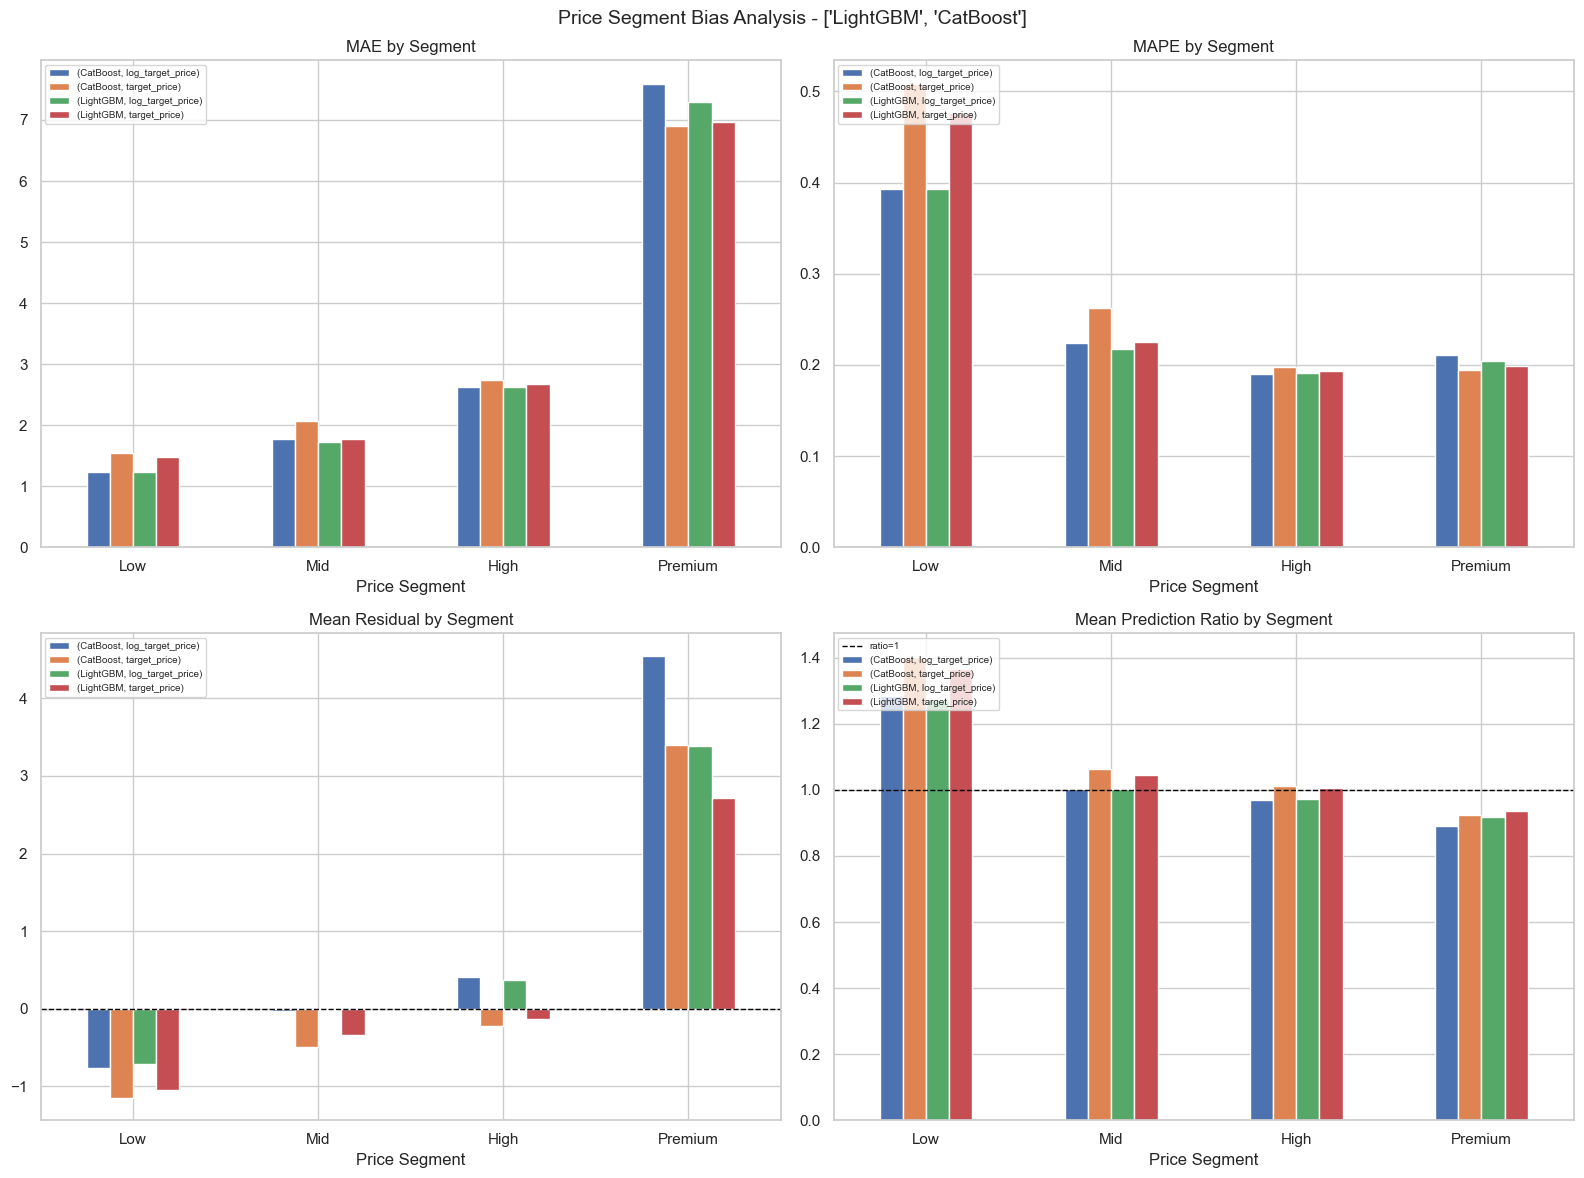

In [52]:
# ── Segment bias plots ─────────────────────────────────────────────────────────
segments_order = ['Low', 'Mid', 'High', 'Premium']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'Price Segment Bias Analysis - {SELECTED_MODELS}', fontsize=14)

for ax, metric, title in zip(
    axes.flatten(),
    ['mae', 'mape', 'mean_residual', 'prediction_ratio_mean'],
    ['MAE by Segment', 'MAPE by Segment', 'Mean Residual by Segment', 'Mean Prediction Ratio by Segment'],
):
    pivot = seg_df.pivot_table(index='price_segment', columns=['model_name', 'target_used'], values=metric)
    pivot = pivot.reindex(segments_order)
    pivot.plot(kind='bar', ax=ax, legend=True)
    if metric == 'mean_residual':
        ax.axhline(0, color='black', linewidth=1, linestyle='--')
    if metric == 'prediction_ratio_mean':
        ax.axhline(1.0, color='black', linewidth=1, linestyle='--', label='ratio=1')
    ax.set_title(title)
    ax.set_xlabel('Price Segment')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(fontsize=7, loc='upper left')

plt.tight_layout()
plt.savefig(DIAGNOSTICS_DIR / 'price_segment_bias_plots.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretation - Price Segment Bias Analysis

The segment-level plots confirm that model errors are not evenly distributed across price ranges.

MAE increases sharply from Low to Premium segments, showing that absolute prediction errors become larger for more expensive listings. This is expected to some extent because high-price listings have larger price scale, but the increase is large enough to suggest weaker model stability in the Premium segment.

MAPE shows the opposite pattern: it is highest in the Low-price segment and lower in Mid, High, and Premium segments. This happens because percentage error is very sensitive when actual prices are small. Therefore, Low-segment MAPE should be interpreted carefully and should be paired with absolute-error metrics.

The mean residual and prediction ratio plots show clear directional bias. Low-price listings are generally overpredicted, with prediction ratios far above 1.0. Premium listings are generally underpredicted, with prediction ratios below 1.0 and positive mean residuals. Mid and High segments are more balanced, with prediction ratios closer to 1.0.

Overall, the main issue is not global bias, but tail-segment bias: the models overestimate low-price listings and underestimate premium listings. The next tuning notebook should therefore evaluate models using segment-aware metrics and consider calibration or weighting strategies for the Low and Premium segments.

In [53]:
# Segment bias interpretation
for model_name in SELECTED_MODELS:
    for target_used in ANALYZED_TARGETS:
        mask = (seg_df["model_name"] == model_name) & (seg_df["target_used"] == target_used)
        s = seg_df[mask].set_index("price_segment")
        if s.empty:
            continue
        print(f"=== {model_name} + {target_used} - Segment Interpretation ===")
        for seg in ["Low", "Premium"]:
            if seg not in s.index:
                continue
            row = s.loc[seg]
            direction = "underpredicts" if row["mean_residual"] > 0 else "overpredicts"
            print(f"  {seg}: mean_residual={row['mean_residual']:,.0f} ({direction}); over_rate={row['overprediction_rate']:.1%}; under_rate={row['underprediction_rate']:.1%}")
        print()


=== LightGBM + target_price - Segment Interpretation ===
  Low: mean_residual=-1 (overpredicts); over_rate=73.0%; under_rate=27.0%
  Premium: mean_residual=3 (underpredicts); over_rate=38.1%; under_rate=61.9%

=== LightGBM + log_target_price - Segment Interpretation ===
  Low: mean_residual=-1 (overpredicts); over_rate=68.6%; under_rate=31.4%
  Premium: mean_residual=3 (underpredicts); over_rate=33.7%; under_rate=66.3%

=== CatBoost + target_price - Segment Interpretation ===
  Low: mean_residual=-1 (overpredicts); over_rate=75.1%; under_rate=24.9%
  Premium: mean_residual=3 (underpredicts); over_rate=35.1%; under_rate=64.9%

=== CatBoost + log_target_price - Segment Interpretation ===
  Low: mean_residual=-1 (overpredicts); over_rate=70.5%; under_rate=29.5%
  Premium: mean_residual=5 (underpredicts); over_rate=28.8%; under_rate=71.2%



### Interpretation - Low vs Premium Segment Directional Bias

The segment interpretation confirms a consistent directional bias across the evaluated model-target combinations. Low-price listings tend to be overpredicted, while Premium listings tend to be underpredicted.

For notebook 10, the primary interpretation should come from `LightGBM + target_price`. The other rows are retained to understand whether the same directional bias appears under log target or CatBoost.

This pattern suggests that the models compress predictions toward the middle of the price distribution: low prices are pushed upward and premium prices are pulled downward. Future tuning should therefore include segment-aware validation and should not rely only on global MAE.

## 7. Premium Segment Deep Dive

Tập trung vào laptops thuộc Premium segment (actual price > Q75) để hiểu underprediction pattern. Diagnostic chính dùng `LightGBM + target_price`; các model-target pair còn lại chỉ đóng vai trò đối chứng.

In [54]:
premium_mask = diag_df['price_segment'] == 'Premium'
premium_df   = diag_df[premium_mask].copy()

print('=== Premium Segment - Summary (SELECTED_MODELS) ===')
prem_rows = []
for (model_name, target_used), grp in premium_df.groupby(['model_name', 'target_used'], observed=True):
    yt  = grp['actual_price'].values
    yp  = grp['predicted_price'].values
    res = grp['residual'].values
    prem_rows.append({
        'model_name':            model_name,
        'target_used':           target_used,
        'count':                 len(yt),
        'mae':                   mean_absolute_error(yt, yp),
        'rmse':                  root_mean_squared_error(yt, yp),
        'mape':                  mean_absolute_percentage_error(yt, yp),
        'mean_residual':         res.mean(),
        'underprediction_rate':  (res > 0).mean(),
        'prediction_ratio_mean': grp['prediction_ratio'].mean(),
        'prediction_ratio_median': grp['prediction_ratio'].median(),
    })

prem_summary = pd.DataFrame(prem_rows)
prem_summary.to_csv(DIAGNOSTICS_DIR / 'premium_segment_diagnostics.csv', index=False)
display(prem_summary)

=== Premium Segment - Summary (SELECTED_MODELS) ===


,model_name,target_used,count,mae,rmse,mape,mean_residual,underprediction_rate,prediction_ratio_mean,prediction_ratio_median
0,CatBoost,log_target_price,365,7.5964,10.4856,0.2113,4.5536,0.7123,0.8906,0.8860
1,CatBoost,target_price,365,6.8942,9.5365,0.1949,3.3936,0.6493,0.9241,0.9124
2,LightGBM,log_target_price,365,7.2946,9.9796,0.2047,3.3899,0.6630,0.9164,0.8963
3,LightGBM,target_price,365,6.9701,9.4236,0.1987,2.7105,0.6192,0.9360,0.9122


### Interpretation - Premium Segment

The Premium segment often shows underprediction across evaluated model-target combinations. For this notebook, the main question is how `LightGBM + target_price` behaves in the upper tail, because that is the primary candidate selected from notebook 09.

The comparison rows remain useful: log-target models can reveal whether the target transformation compresses premium predictions, while CatBoost rows provide a secondary boosting baseline. However, a secondary candidate should not replace the primary diagnostic pair unless the post-tuning comparison shows a materially better balance across MAE, RMSE, R2, and segment metrics.

The next tuning notebook should monitor Premium RMSE, Premium underprediction rate, and prediction ratio separately for `LightGBM + target_price` first. Potential improvements include premium sample weighting, feature engineering for rare high-value configurations, and calibration validated on a separate validation split.

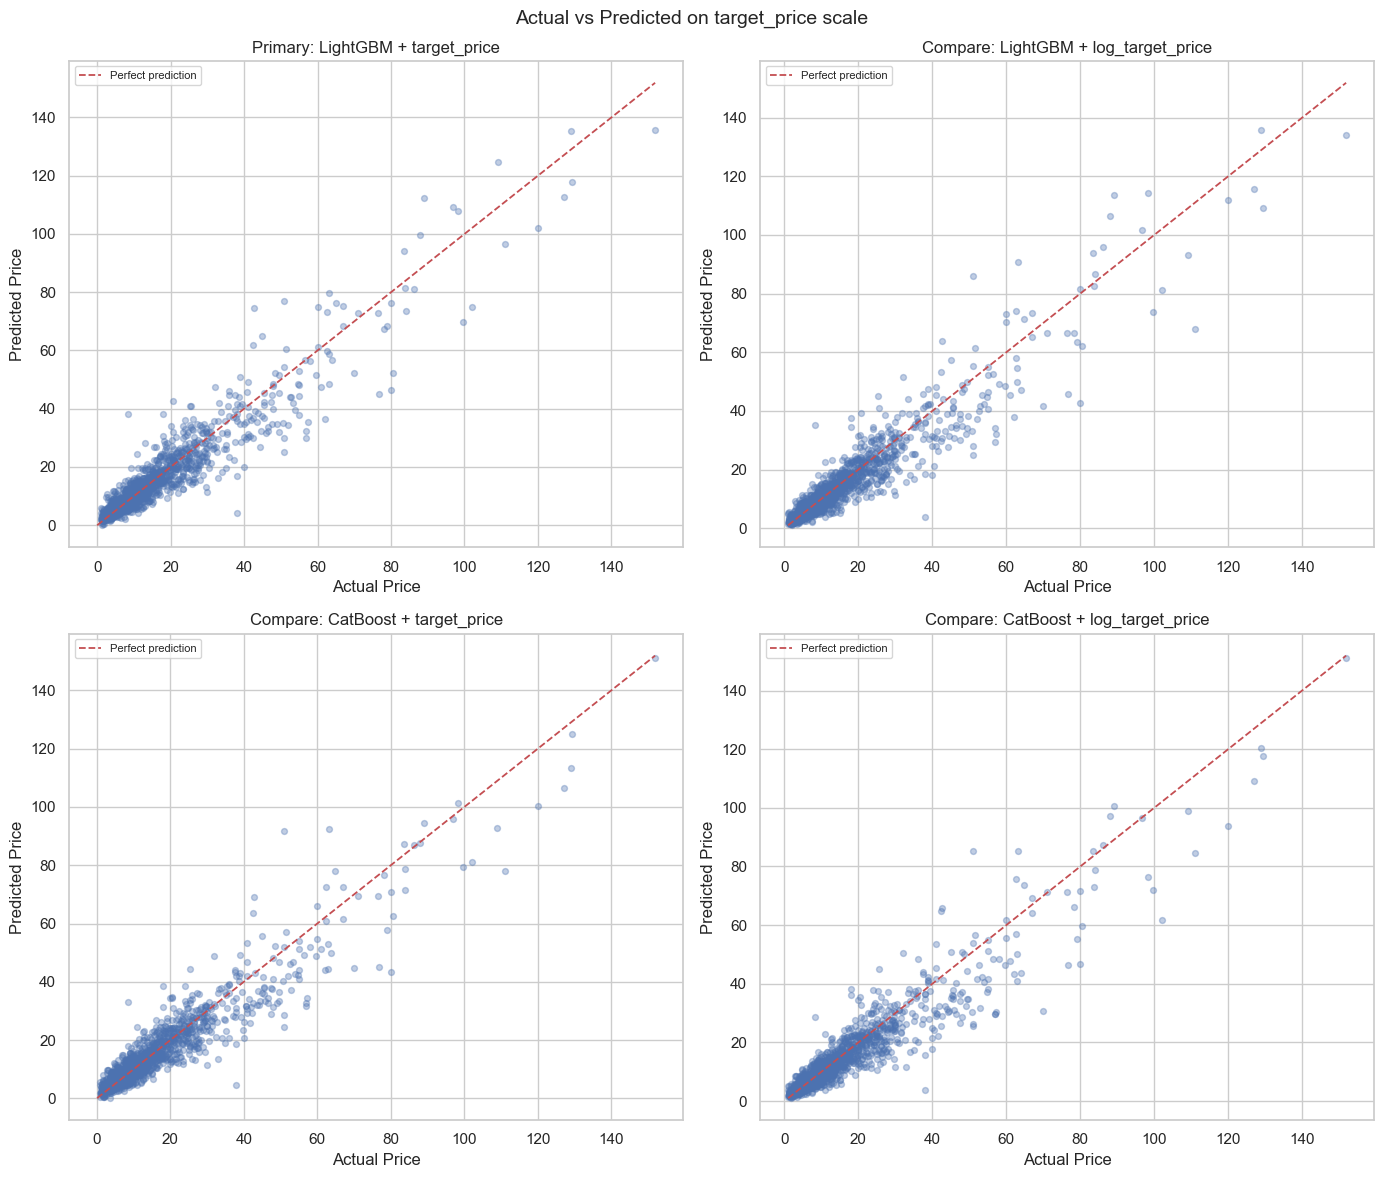

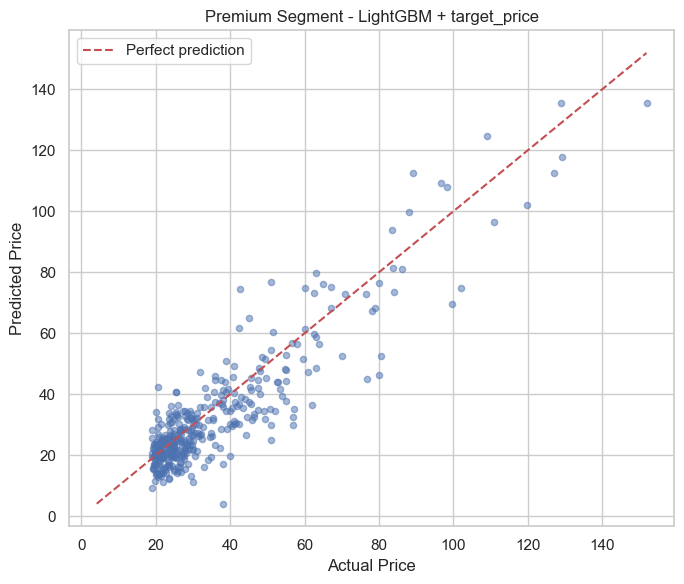

In [55]:
# Actual vs Predicted: primary candidate first, secondary candidates as comparison
plot_pairs = [(PRIMARY_MODEL, PRIMARY_TARGET)] + [
    pair for pair in available_model_targets if pair != (PRIMARY_MODEL, PRIMARY_TARGET)
]

n_pairs = len(plot_pairs)
n_cols = 2
n_rows = int(np.ceil(n_pairs / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 6 * n_rows))
axes = np.array(axes).reshape(-1)
fig.suptitle("Actual vs Predicted on target_price scale", fontsize=14)

for ax, (model_name, target_used) in zip(axes, plot_pairs):
    grp = diag_df[(diag_df["model_name"] == model_name) & (diag_df["target_used"] == target_used)]
    ax.scatter(grp["actual_price"], grp["predicted_price"], alpha=0.35, s=18)
    lim_min = min(grp["actual_price"].min(), grp["predicted_price"].min())
    lim_max = max(grp["actual_price"].max(), grp["predicted_price"].max())
    ax.plot([lim_min, lim_max], [lim_min, lim_max], "r--", linewidth=1.3, label="Perfect prediction")
    title_prefix = "Primary: " if (model_name, target_used) == (PRIMARY_MODEL, PRIMARY_TARGET) else "Compare: "
    ax.set_title(f"{title_prefix}{model_name} + {target_used}")
    ax.set_xlabel("Actual Price")
    ax.set_ylabel("Predicted Price")
    ax.legend(fontsize=8)

for ax in axes[n_pairs:]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(DIAGNOSTICS_DIR / f"{output_prefix}_actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()

# Premium-only view for the primary diagnostic pair.
main_premium_plot = premium_df[(premium_df["model_name"] == PRIMARY_MODEL) & (premium_df["target_used"] == PRIMARY_TARGET)]
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(main_premium_plot["actual_price"], main_premium_plot["predicted_price"], alpha=0.5, s=20)
lim_min = min(main_premium_plot["actual_price"].min(), main_premium_plot["predicted_price"].min())
lim_max = max(main_premium_plot["actual_price"].max(), main_premium_plot["predicted_price"].max())
ax.plot([lim_min, lim_max], [lim_min, lim_max], "r--", linewidth=1.5, label="Perfect prediction")
ax.set_title(f"Premium Segment - {PRIMARY_MODEL} + {PRIMARY_TARGET}")
ax.set_xlabel("Actual Price")
ax.set_ylabel("Predicted Price")
ax.legend()
plt.tight_layout()
plt.savefig(DIAGNOSTICS_DIR / f"{output_prefix}_premium_actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation - Actual vs Predicted

Biểu đồ Actual vs Predicted chính được vẽ cho `LightGBM + target_price`, là candidate chính từ notebook 09. Các điểm càng gần đường chéo thì mô hình dự đoán càng chính xác. Vì target được train trực tiếp trên giá thật, kết quả diagnostic phản ánh trực tiếp sai số theo đơn vị triệu VND.

Các biểu đồ phụ cho `LightGBM + log_target_price`, `CatBoost + target_price`, và `CatBoost + log_target_price` được giữ lại để so sánh. Chúng giúp kiểm tra liệu log target có cải thiện relative error hay tạo compression ở vùng giá cao.

Phần premium-only view tập trung vào primary pair để xem rõ hơn underprediction ở upper tail. Đây là khu vực cần được theo dõi trong notebook tuning tiếp theo.

In [56]:
# Premium: top error cases for primary pair
main_premium = premium_df[(premium_df["model_name"] == PRIMARY_MODEL) & (premium_df["target_used"] == PRIMARY_TARGET)].copy()
top20_premium = main_premium.nlargest(20, "absolute_error")
top20_premium.to_csv(DIAGNOSTICS_DIR / "premium_top_error_cases.csv", index=False)
print(f"=== Top 20 Premium Error Cases ({PRIMARY_MODEL} + {PRIMARY_TARGET}) ===")
display(top20_premium[["sample_id", "actual_price", "predicted_price", "residual", "absolute_error", "absolute_percentage_error"]].head(20))


=== Top 20 Premium Error Cases (LightGBM + target_price) ===


,sample_id,actual_price,predicted_price,residual,absolute_error,absolute_percentage_error
909,5008,38.0000,4.1540,33.8460,33.8460,0.8907
1120,6456,79.9900,46.3654,33.6246,33.6246,0.4204
523,5983,42.7000,74.5314,-31.8314,31.8314,0.7455
1319,6753,76.7900,44.9923,31.7977,31.7977,0.4141
72,5735,99.6900,69.7063,29.9837,29.9837,0.3008
438,5683,80.4900,52.4239,28.0661,28.0661,0.3487
844,6799,56.9900,29.9203,27.0697,27.0697,0.4750
1149,6067,102.0000,74.9333,27.0667,27.0667,0.2654
870,3296,51.0000,25.1019,25.8981,25.8981,0.5078
420,7187,50.9990,76.8330,-25.8340,25.8340,0.5066


### Interpretation - Top Premium Error Cases

The top Premium error cases are generated from the primary pair `LightGBM + target_price`. These rows show where the selected candidate misses most in absolute VND terms.

These cases should be inspected further in the original feature data. Potential causes may include rare high-value product attributes, sparse premium examples, missing feature interactions, or outlier-like listings.

CatBoost and log-target variants remain useful for checking whether the same premium cases are difficult across model families and target strategies, but the main handoff to the next notebook should start from the LightGBM raw-target errors.

## 8. Low-Price Segment Deep Dive

Low-price laptops (actual price ≤ Q25) có thể bị overpredict do mean-reversion effects trong tree models.

In [57]:
low_mask = diag_df["price_segment"] == "Low"
low_df = diag_df[low_mask].copy()

print("=== Low-Price Segment Summary ===")
low_rows = []
for (model_name, target_used), grp in low_df.groupby(["model_name", "target_used"], observed=True):
    metrics = compute_error_metrics(grp["actual_price"], grp["predicted_price"], grp["residual"], grp["absolute_percentage_error"])
    low_rows.append({
        "model_name": model_name,
        "target_used": target_used,
        "count": len(grp),
        "mae": metrics["mae"],
        "rmse": metrics["rmse"],
        "mape": metrics["mape"],
        "mean_residual": metrics["mean_residual"],
        "overprediction_rate": metrics["overprediction_rate"],
        "prediction_ratio_mean": grp["prediction_ratio"].mean(),
    })
low_summary = pd.DataFrame(low_rows)
low_summary.to_csv(DIAGNOSTICS_DIR / "low_price_segment_diagnostics.csv", index=False)
display(low_summary)


=== Low-Price Segment Summary ===


,model_name,target_used,count,mae,rmse,mape,mean_residual,overprediction_rate,prediction_ratio_mean
0,CatBoost,log_target_price,366,1.2282,1.6663,0.3925,-0.7654,0.7049,1.2837
1,CatBoost,target_price,366,1.5503,2.1213,0.5085,-1.1540,0.7514,1.4036
2,LightGBM,log_target_price,366,1.2271,1.6795,0.3929,-0.7114,0.6858,1.2709
3,LightGBM,target_price,366,1.4731,2.0203,0.4762,-1.0535,0.7295,1.3658


### Interpretation - Low-Price Segment

The Low-price segment often shows overprediction because models tend to pull very cheap listings upward toward more common price levels. For this notebook, the key readout is the Low-segment behavior of `LightGBM + target_price`.

Compared with raw-target models, log-target models may reduce Low-segment overprediction or relative error in some runs, but that trade-off must be weighed against premium compression, RMSE, and R2 on the real-price scale.

The next tuning notebook should monitor Low-segment MAPE, overprediction rate, and prediction ratio for `LightGBM + target_price`, then compare the result against `LightGBM + log_target_price` and CatBoost variants after tuning.

In [58]:
# Low-price: top overpredicted cases for primary pair
main_low = low_df[(low_df["model_name"] == PRIMARY_MODEL) & (low_df["target_used"] == PRIMARY_TARGET)].copy()
top_low_over = main_low[main_low["residual"] < 0].nsmallest(20, "residual")
top_low_over.to_csv(DIAGNOSTICS_DIR / "low_price_top_error_cases.csv", index=False)
print("=== Top 20 Overpredicted Low-Price Cases ===")
display(top_low_over[["sample_id", "actual_price", "predicted_price", "residual", "absolute_percentage_error"]].head(20))

over_rate = (main_low["residual"] < 0).mean() if len(main_low) else np.nan
print(f"\nOverprediction rate for Low-price segment ({PRIMARY_MODEL} + {PRIMARY_TARGET}): {over_rate:.1%}")
if over_rate > 0.55:
    print("Model tends to overpredict low-price laptops, consistent with mean-reversion.")
else:
    print("No strong overprediction bias in the low-price segment for the primary pair.")


=== Top 20 Overpredicted Low-Price Cases ===


,sample_id,actual_price,predicted_price,residual,absolute_percentage_error
1213,5045,2.8000,10.6244,-7.8244,2.7944
846,3878,4.2000,11.7416,-7.5416,1.7956
1450,527,4.5000,11.7416,-7.2416,1.6092
534,4394,2.5000,9.7239,-7.2239,2.8896
486,1144,2.9000,9.8004,-6.9004,2.3794
123,5857,4.8450,11.3667,-6.5217,1.3461
841,6060,5.6900,12.1606,-6.4706,1.1372
9,1662,4.7000,10.6794,-5.9794,1.2722
566,3982,3.0000,8.6887,-5.6887,1.8962
235,5242,5.5000,10.8284,-5.3284,0.9688



Overprediction rate for Low-price segment (LightGBM + target_price): 73.0%
Model tends to overpredict low-price laptops, consistent with mean-reversion.


### Interpretation - Top Overpredicted Low-Price Cases

The top Low-price error cases confirm systematic overprediction in the lower tail of the price distribution. All listed cases have negative residuals, meaning the predicted price is higher than the actual price.

Several examples show very large relative errors because the actual prices are extremely small. For instance, a listing with an actual price of 1.00 is predicted at around 14.35, producing an absolute percentage error above 13. This explains why the Low segment has much higher MAPE than other segments.

This pattern suggests mean-reversion: the model pulls very low-price listings upward toward more common price levels instead of preserving the lower tail. The next tuning notebook should therefore monitor Low-segment MAPE, overprediction rate, and prediction ratio separately. Potential fixes include low-price calibration, segment-specific correction, or reviewing whether extremely low prices represent valid listings or data-quality issues.

## 9. Top Error Case Analysis

Xem xét các samples có lỗi lớn nhất để hiểu nguồn gốc sai số — từ price segment cụ thể hay từ data quality issues.

In [59]:
base_cols = ['sample_id', 'actual_price', 'predicted_price', 'residual',
             'absolute_error', 'absolute_percentage_error', 'price_segment']

primary_error_df = diag_df[
    (diag_df['model_name'] == PRIMARY_MODEL) & (diag_df['target_used'] == PRIMARY_TARGET)
].copy()

primary_top_abs   = primary_error_df.nlargest(30, 'absolute_error')
primary_top_pct   = primary_error_df.nlargest(30, 'absolute_percentage_error')
primary_top_under = primary_error_df.nlargest(30, 'residual')
primary_top_over  = primary_error_df.nsmallest(30, 'residual')

primary_top_abs[base_cols].to_csv(DIAGNOSTICS_DIR / f'{output_prefix}_top_absolute_error.csv', index=False)
primary_top_pct[base_cols].to_csv(DIAGNOSTICS_DIR / f'{output_prefix}_top_percentage_error.csv', index=False)
primary_top_under[base_cols].to_csv(DIAGNOSTICS_DIR / f'{output_prefix}_top_underpredicted.csv', index=False)
primary_top_over[base_cols].to_csv(DIAGNOSTICS_DIR / f'{output_prefix}_top_overpredicted.csv', index=False)

print(f'=== Primary: {PRIMARY_MODEL} + {PRIMARY_TARGET} - Top 10 by Absolute Error ===')
display(primary_top_abs[base_cols].head(10))
print(f'\n=== Primary: {PRIMARY_MODEL} + {PRIMARY_TARGET} - Segment distribution in Top 30 Absolute Errors ===')
print(primary_top_abs['price_segment'].value_counts())

# Secondary comparison exports for the same primary target.
for model_name in SELECTED_MODELS:
    main_all = diag_df[
        (diag_df['model_name'] == model_name) & (diag_df['target_used'] == PRIMARY_TARGET)
    ].copy()

    if main_all.empty:
        continue

    top_abs   = main_all.nlargest(30, 'absolute_error')
    top_pct   = main_all.nlargest(30, 'absolute_percentage_error')
    top_under = main_all.nlargest(30, 'residual')
    top_over  = main_all.nsmallest(30, 'residual')

    fn = safe_filename(model_name, PRIMARY_TARGET)
    top_abs[base_cols].to_csv(DIAGNOSTICS_DIR / f'top_absolute_error_{fn}.csv', index=False)
    top_pct[base_cols].to_csv(DIAGNOSTICS_DIR / f'top_percentage_error_{fn}.csv', index=False)
    top_under[base_cols].to_csv(DIAGNOSTICS_DIR / f'top_underpredicted_{fn}.csv', index=False)
    top_over[base_cols].to_csv(DIAGNOSTICS_DIR / f'top_overpredicted_{fn}.csv', index=False)

print('\nSaved primary top-error files and secondary comparison top-error files.')

=== Primary: LightGBM + target_price - Top 10 by Absolute Error ===


,sample_id,actual_price,predicted_price,residual,absolute_error,absolute_percentage_error,price_segment
909,5008,38.0000,4.1540,33.8460,33.8460,0.8907,Premium
1120,6456,79.9900,46.3654,33.6246,33.6246,0.4204,Premium
523,5983,42.7000,74.5314,-31.8314,31.8314,0.7455,Premium
1319,6753,76.7900,44.9923,31.7977,31.7977,0.4141,Premium
72,5735,99.6900,69.7063,29.9837,29.9837,0.3008,Premium
1112,6072,8.3900,38.2120,-29.8220,29.8220,3.5545,Mid
438,5683,80.4900,52.4239,28.0661,28.0661,0.3487,Premium
844,6799,56.9900,29.9203,27.0697,27.0697,0.4750,Premium
1149,6067,102.0000,74.9333,27.0667,27.0667,0.2654,Premium
870,3296,51.0000,25.1019,25.8981,25.8981,0.5078,Premium



=== Primary: LightGBM + target_price - Segment distribution in Top 30 Absolute Errors ===
price_segment
Premium    28
Mid         1
High        1
Low         0
Name: count, dtype: int64

Saved primary top-error files and secondary comparison top-error files.


### Interpretation - Top Error Cases

Top absolute errors and top percentage errors are generated first for the primary pair `LightGBM + target_price`. This keeps the main error review aligned with the selected candidate from notebook 09.

The largest absolute errors are expected to concentrate in higher price segments because misses in expensive laptops have larger VND magnitude. Percentage errors can look extreme in the Low segment because the denominator is small.

Secondary exports for CatBoost on `target_price` are kept for comparison, while log-target trade-offs are covered in the dedicated log-vs-raw section. CatBoost/log-target remains a useful benchmark, but it is not the main diagnostic path in this notebook.

## 10. Log-Target Compression Check

So sánh `log_target_price` vs `target_price` theo price segment để phát hiện xem log-transform có nén prediction ở vùng giá cao không (prediction_ratio < 1 ở Premium).

In [60]:
for model_name in SELECTED_MODELS:
    log_col = f'pred_{safe_filename(model_name, "log_target_price")}'
    raw_col = f'pred_{safe_filename(model_name, "target_price")}'

    if log_col not in predictions_raw.columns or raw_col not in predictions_raw.columns:
        print(f'{model_name}: one or both target columns not found - skipping compression check.')
        continue

    actual   = predictions_raw[actual_col].values
    pred_log = predictions_raw[log_col].values
    pred_raw = predictions_raw[raw_col].values

    comp_df = pd.DataFrame({
        'actual_price':        actual,
        'pred_log':            pred_log,
        'pred_raw':            pred_raw,
        'residual_log':        actual - pred_log,
        'residual_raw':        actual - pred_raw,
        'prediction_ratio_log': pred_log / (actual + 1e-9),
        'prediction_ratio_raw': pred_raw / (actual + 1e-9),
    })
    comp_df['price_segment'] = comp_df['actual_price'].apply(assign_segment)
    comp_df['price_segment'] = pd.Categorical(
        comp_df['price_segment'], categories=['Low', 'Mid', 'High', 'Premium'], ordered=True
    )

    seg_comp = comp_df.groupby('price_segment', observed=True).agg(
        count=('actual_price', 'count'),
        pred_ratio_log_mean=('prediction_ratio_log', 'mean'),
        pred_ratio_raw_mean=('prediction_ratio_raw', 'mean'),
        residual_log_mean=('residual_log', 'mean'),
        residual_raw_mean=('residual_raw', 'mean'),
        underpred_log=('residual_log', lambda x: (x > 0).mean()),
        underpred_raw=('residual_raw', lambda x: (x > 0).mean()),
    ).reset_index()

    seg_comp.to_csv(DIAGNOSTICS_DIR / f'{MODEL_NAME_FOR_FILE.get(model_name, model_name)}_log_vs_raw_compression.csv', index=False)
    print(f'=== {model_name} - Log vs Raw Compression Check by Segment ===')
    display(seg_comp)

    # Interpretation
    if 'Premium' in seg_comp['price_segment'].values:
        prem = seg_comp[seg_comp['price_segment'] == 'Premium'].iloc[0]
        if prem['pred_ratio_log_mean'] < prem['pred_ratio_raw_mean']:
            print(f'Log-target has lower prediction ratio than raw-target in Premium segment.')
            print(f'    -> Log-transform compresses high-price predictions - underprediction bias.')
        else:
            print(f'Log-target does not compress Premium predictions more than raw-target.')
    print()

=== LightGBM - Log vs Raw Compression Check by Segment ===


,price_segment,count,pred_ratio_log_mean,pred_ratio_raw_mean,residual_log_mean,residual_raw_mean,underpred_log,underpred_raw
0,Low,366,1.2709,1.3658,-0.7114,-1.0535,0.3142,0.2705
1,Mid,364,1.0030,1.0450,-0.0136,-0.3386,0.5495,0.4918
2,High,365,0.9712,1.0060,0.3717,-0.1323,0.5836,0.5315
3,Premium,365,0.9164,0.9360,3.3899,2.7105,0.6630,0.6192


Log-target has lower prediction ratio than raw-target in Premium segment.
    -> Log-transform compresses high-price predictions - underprediction bias.

=== CatBoost - Log vs Raw Compression Check by Segment ===


,price_segment,count,pred_ratio_log_mean,pred_ratio_raw_mean,residual_log_mean,residual_raw_mean,underpred_log,underpred_raw
0,Low,366,1.2837,1.4036,-0.7654,-1.1540,0.2951,0.2486
1,Mid,364,1.0039,1.0640,-0.0295,-0.4927,0.5632,0.4918
2,High,365,0.9686,1.0133,0.4029,-0.2194,0.5863,0.5151
3,Premium,365,0.8906,0.9241,4.5536,3.3936,0.7123,0.6493


Log-target has lower prediction ratio than raw-target in Premium segment.
    -> Log-transform compresses high-price predictions - underprediction bias.



### Interpretation - Log vs Raw Target Compression

The log-vs-raw comparison is retained as a secondary target-strategy check. It helps test whether `log_target_price` compresses high-price predictions more than direct training on `target_price`.

For the current diagnostic direction, this section should be read as supporting evidence rather than a primary model-selection rule. `LightGBM + target_price` remains the main pair unless a post-tuning comparison shows that another configuration is materially better across MAE, RMSE, R2, and segment behavior.

The next tuning notebook should tune `LightGBM + target_price` first, then compare again with `LightGBM + log_target_price`, `CatBoost + target_price`, and `CatBoost + log_target_price` using segment-aware validation.

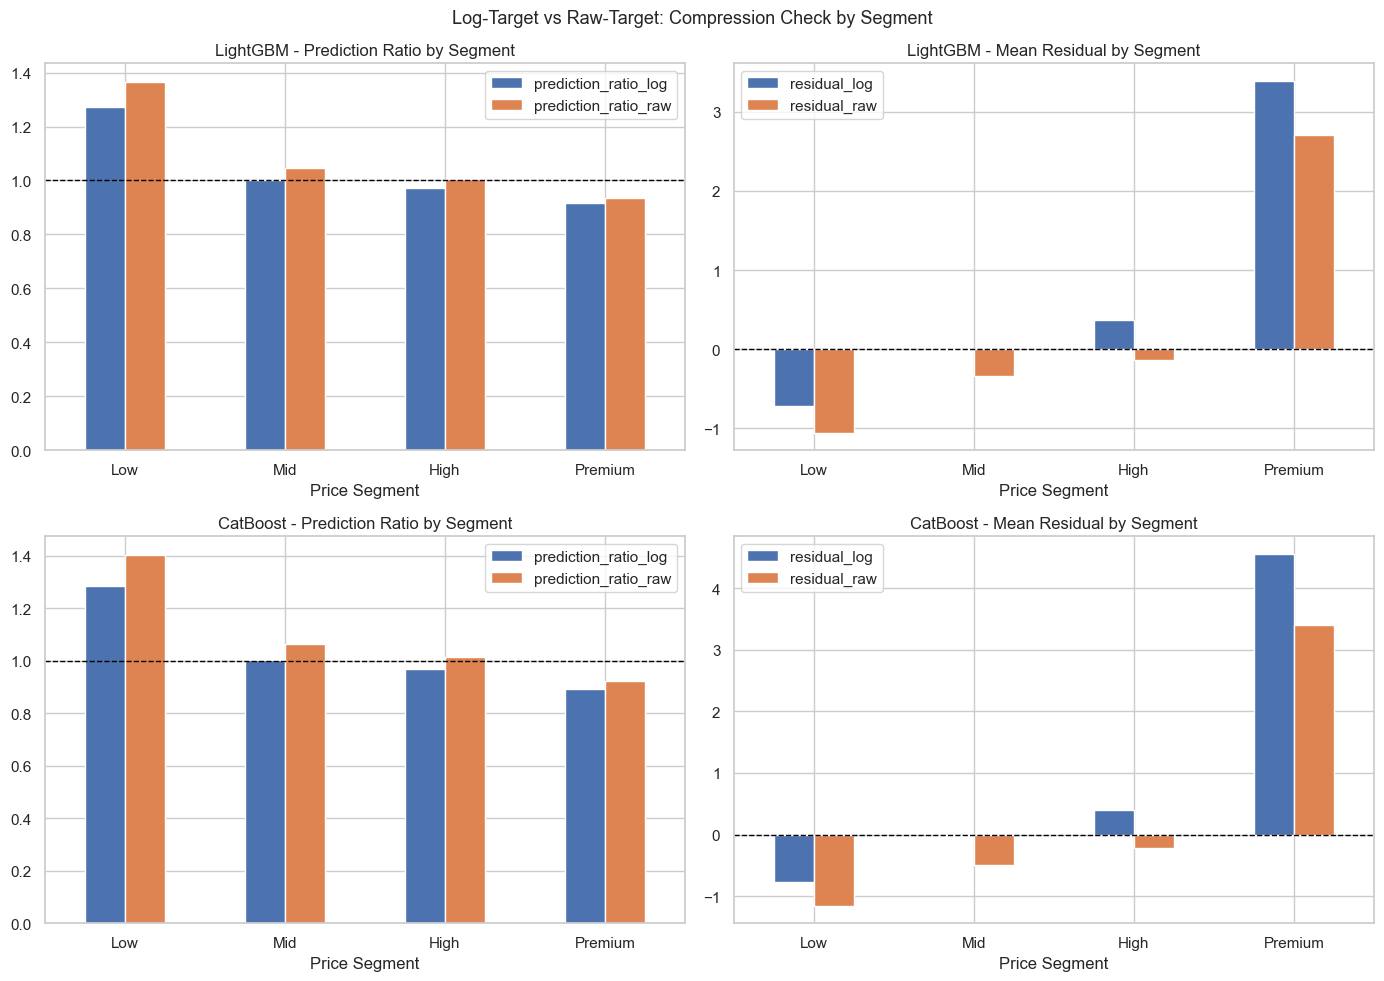

In [61]:
# Compression plots: compare available models with both targets present
compression_models = [m for m in SELECTED_MODELS if (m, "log_target_price") in available_model_targets and (m, "target_price") in available_model_targets]
if compression_models:
    fig, axes = plt.subplots(len(compression_models), 2, figsize=(14, 5 * len(compression_models)))
    if len(compression_models) == 1:
        axes = np.array([axes])
    fig.suptitle("Log-Target vs Raw-Target: Compression Check by Segment", fontsize=13)
    for ax_row, model_name in zip(axes, compression_models):
        log_col = expected_prediction_col(model_name, "log_target_price")
        raw_col = expected_prediction_col(model_name, "target_price")
        actual = predictions_raw[actual_col].values
        pred_log = predictions_raw[log_col].values
        pred_raw = predictions_raw[raw_col].values
        comp_tmp = pd.DataFrame({
            "actual_price": actual,
            "prediction_ratio_log": pred_log / (actual + 1e-9),
            "prediction_ratio_raw": pred_raw / (actual + 1e-9),
            "residual_log": actual - pred_log,
            "residual_raw": actual - pred_raw,
        })
        comp_tmp["price_segment"] = pd.Categorical(comp_tmp["actual_price"].apply(assign_segment), categories=["Low", "Mid", "High", "Premium"], ordered=True)
        seg_c = comp_tmp.groupby("price_segment", observed=True)[["prediction_ratio_log", "prediction_ratio_raw", "residual_log", "residual_raw"]].mean()
        seg_c[["prediction_ratio_log", "prediction_ratio_raw"]].plot(kind="bar", ax=ax_row[0], title=f"{model_name} - Prediction Ratio by Segment")
        ax_row[0].axhline(1.0, color="black", linestyle="--", linewidth=1)
        ax_row[0].set_xlabel("Price Segment")
        ax_row[0].tick_params(axis="x", rotation=0)
        seg_c[["residual_log", "residual_raw"]].plot(kind="bar", ax=ax_row[1], title=f"{model_name} - Mean Residual by Segment")
        ax_row[1].axhline(0, color="black", linestyle="--", linewidth=1)
        ax_row[1].set_xlabel("Price Segment")
        ax_row[1].tick_params(axis="x", rotation=0)
    plt.tight_layout()
    plt.savefig(DIAGNOSTICS_DIR / "log_vs_raw_compression_plot.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No model has both log_target_price and target_price prediction columns; compression plot skipped.")


### Interpretation - Log Target vs Raw Target Compression by Segment

The compression check shows the target-transformation trade-off by price segment. Log-target models can improve relative-error behavior, but they may also pull high-price predictions closer to the center of the distribution.

For both LightGBM and CatBoost, this section is useful as a diagnostic benchmark. It should not override the notebook 09 decision to use `numeric + LightGBM + target_price` as the primary candidate for notebook 10.

Key metrics to carry into tuning are Premium prediction ratio, Premium underprediction rate, Low prediction ratio, Low overprediction rate, MAE, RMSE, and R2 on the original price scale.

## 11. Outlier and Data Quality Investigation

Flag các cases có thể là data quality issues. Tiêu chí:

- Absolute percentage error > 200%
- Actual price cao nhưng predicted price rất thấp (prediction_ratio < 0.5)
- Actual price thấp nhưng predicted price rất cao (prediction_ratio > 2.0)

> **Lưu ý**: Không xóa records ở notebook này. Chỉ flag để review thủ công.

In [62]:
for model_name in SELECTED_MODELS:
    main_for_outliers = diag_df[
        (diag_df['model_name'] == model_name) & (diag_df['target_used'] == PRIMARY_TARGET)
    ].copy()

    if main_for_outliers.empty:
        continue

    outlier_flags = (
        (main_for_outliers['absolute_percentage_error'] > 2.0) |
        (main_for_outliers['prediction_ratio'] < 0.5) |
        (main_for_outliers['prediction_ratio'] > 2.0)
    )

    potential_outliers = main_for_outliers[outlier_flags].copy()
    print(f'{model_name}: {len(potential_outliers)} potential outliers of {len(main_for_outliers)}')

    out_cols = ['sample_id', 'actual_price', 'predicted_price', 'residual',
                'absolute_percentage_error', 'prediction_ratio', 'price_segment']

    fn = MODEL_NAME_FOR_FILE.get(model_name, model_name)
    potential_outliers[out_cols].to_csv(
        DIAGNOSTICS_DIR / f'potential_outliers_{fn}.csv', index=False
    )

    display(
        potential_outliers[out_cols]
        .sort_values('absolute_percentage_error', ascending=False)
        .head(10)
    )
    print(f'  Saved: potential_outliers_{fn}.csv\n')

LightGBM: 72 potential outliers of 1460


,sample_id,actual_price,predicted_price,residual,absolute_percentage_error,prediction_ratio,price_segment
492,3172,1.0000,6.0115,-5.0115,5.0115,6.0115,Low
1112,6072,8.3900,38.2120,-29.8220,3.5545,4.5545,Mid
179,4352,1.0000,4.3535,-3.3535,3.3535,4.3535,Low
180,1672,1.3000,5.5769,-4.2769,3.2900,4.2900,Low
534,4394,2.5000,9.7239,-7.2239,2.8896,3.8896,Low
1213,5045,2.8000,10.6244,-7.8244,2.7944,3.7944,Low
486,1144,2.9000,9.8004,-6.9004,2.3794,3.3794,Low
830,3518,1.2000,3.7437,-2.5437,2.1198,3.1198,Low
241,3217,1.7900,5.5335,-3.7435,2.0913,3.0913,Low
566,3982,3.0000,8.6887,-5.6887,1.8962,2.8962,Low


  Saved: potential_outliers_LightGBM.csv

CatBoost: 79 potential outliers of 1460


,sample_id,actual_price,predicted_price,residual,absolute_percentage_error,prediction_ratio,price_segment
3412,3172,1.0000,5.5169,-4.5169,4.5169,5.5169,Low
3099,4352,1.0000,4.7265,-3.7265,3.7265,4.7265,Low
3883,734,1.7000,7.9362,-6.2362,3.6684,4.6684,Low
4032,6072,8.3900,33.0717,-24.6817,2.9418,3.9418,Mid
3100,1672,1.3000,4.8051,-3.5051,2.6962,3.6962,Low
3691,764,1.8000,6.1665,-4.3665,2.4258,3.4258,Low
3406,1144,2.9000,9.6298,-6.7298,2.3206,3.3206,Low
3750,3518,1.2000,3.9540,-2.7540,2.2950,3.2950,Low
3161,3217,1.7900,5.8477,-4.0577,2.2669,3.2669,Low
3486,3982,3.0000,9.7973,-6.7973,2.2658,3.2658,Low


  Saved: potential_outliers_CatBoost.csv



### Interpretation - Potential Outliers

The potential outlier check identifies cases with extremely large relative prediction errors. Most of the top flagged cases are in the Low-price segment, where actual prices are very small but predicted prices are much higher.

For example, some listings with actual prices around 1–3 are predicted around 10–18. This creates very large prediction ratios and absolute percentage errors. These cases are a major reason why the Low segment has high MAPE and strong overprediction bias.

However, these rows should be treated as potential model-error outliers, not automatically as invalid data. Some may be valid very low-price listings, while others may reflect data-quality issues, unusual promotions, missing feature information, or rare product configurations.

The next step should be to inspect these samples in the original feature dataset before removing or correcting them. If they are valid, the model should be improved through Low-segment calibration or segment-aware training rather than simply dropping them.

## 12. Exploratory Correction Strategy Experiments

> **Warning**: Các thử nghiệm này chỉ mang tính exploratory. Corrections được compute và evaluate trên cùng test set, nên metrics là test-set optimistic và không nên report như final model performance.

Ba chiến lược post-hoc correction được test:

1. **Additive segment correction**: cộng mean residual theo segment
2. **Multiplicative segment correction**: chia prediction cho median prediction ratio theo segment
3. **Premium-only correction**: chỉ áp dụng correction cho Premium laptops

Any correction method should be validated with cross-validation or a separate validation split in the next tuning notebook.


In [63]:
def evaluate_correction(actual, predicted_corrected, name):
    metrics = compute_error_metrics(actual, predicted_corrected)
    return {
        "correction": name,
        "mae": metrics["mae"],
        "rmse": metrics["rmse"],
        "mape": metrics["mape"],
        "median_absolute_error": metrics["median_absolute_error"],
        "mean_residual": metrics["mean_residual"],
        "underprediction_rate": metrics["underprediction_rate"],
        "severe_error_rate": metrics["severe_error_rate"],
        "extreme_error_rate": metrics["extreme_error_rate"],
        "r2": r2_score(actual, predicted_corrected),
    }

all_corr_results = {}
for model_name in SELECTED_MODELS:
    base = diag_df[(diag_df["model_name"] == model_name) & (diag_df["target_used"] == PRIMARY_TARGET)].copy()
    if base.empty:
        continue
    actual_arr = base["actual_price"].values
    predicted_arr = base["predicted_price"].values
    seg_stats = base.groupby("price_segment", observed=True).agg(mean_residual=("residual", "mean"), median_ratio=("prediction_ratio", "median")).to_dict("index")
    pred_additive = predicted_arr.copy()
    pred_multiplicative = predicted_arr.copy()
    pred_premium_only = predicted_arr.copy()
    for i, (seg, row) in enumerate(zip(base["price_segment"], predicted_arr)):
        key = str(seg)
        if key in seg_stats:
            pred_additive[i] = row + seg_stats[key]["mean_residual"]
            ratio = seg_stats[key]["median_ratio"]
            if ratio > 0:
                pred_multiplicative[i] = row / ratio
        if key == "Premium" and "Premium" in seg_stats:
            pred_premium_only[i] = row + seg_stats["Premium"]["mean_residual"]
    corr_df = pd.DataFrame([
        evaluate_correction(actual_arr, predicted_arr, "No correction (baseline)"),
        evaluate_correction(actual_arr, pred_additive, "Additive segment correction"),
        evaluate_correction(actual_arr, pred_multiplicative, "Multiplicative segment correction"),
        evaluate_correction(actual_arr, pred_premium_only, "Premium-only additive correction"),
    ])
    fn = MODEL_NAME_FOR_FILE.get(model_name, model_name)
    corr_df.to_csv(DIAGNOSTICS_DIR / f"correction_experiment_{fn}.csv", index=False)
    all_corr_results[model_name] = corr_df
    print(f"=== {model_name} - Exploratory Correction Results (test-set optimistic) ===")
    display(corr_df)
    print("Validate any correction via cross-validation or a held-out validation split before reporting.\n")


=== LightGBM - Exploratory Correction Results (test-set optimistic) ===


,correction,mae,rmse,mape,median_absolute_error,mean_residual,underprediction_rate,severe_error_rate,extreme_error_rate,r2
0,No correction (baseline),3.2246,5.3365,0.2734,1.8200,0.2960,0.4781,0.1274,0.0336,0.8930
1,Additive segment correction,3.1023,5.1313,0.2519,1.7673,-0.0000,0.5534,0.1034,0.0205,0.9010
2,Multiplicative segment correction,3.1576,5.4162,0.2432,1.7202,-0.3700,0.4993,0.0979,0.0164,0.8897
3,Premium-only additive correction,3.1413,5.1615,0.2720,1.7887,-0.3816,0.4473,0.1295,0.0336,0.8999


Validate any correction via cross-validation or a held-out validation split before reporting.

=== CatBoost - Exploratory Correction Results (test-set optimistic) ===


,correction,mae,rmse,mape,median_absolute_error,mean_residual,underprediction_rate,severe_error_rate,extreme_error_rate,r2
0,No correction (baseline),3.3104,5.4136,0.2912,1.9472,0.3814,0.4760,0.1445,0.0363,0.8898
1,Additive segment correction,3.1902,5.1012,0.2685,1.9933,0.0000,0.5384,0.1151,0.0240,0.9022
2,Multiplicative segment correction,3.1812,5.2494,0.2532,1.8430,-0.1534,0.4993,0.1055,0.0199,0.8964
3,Premium-only additive correction,3.2287,5.1409,0.2911,2.0189,-0.4670,0.4281,0.1459,0.0363,0.9007


Validate any correction via cross-validation or a held-out validation split before reporting.



### Interpretation - Exploratory Correction Results

The correction experiments are exploratory and test-set optimistic. They are useful for identifying whether segment-level bias is systematic, but they should not be reported as final model performance.

The main correction readout should start from `LightGBM + target_price`. Secondary rows for CatBoost are retained to check whether the same correction pattern appears across boosting implementations.

Any additive, multiplicative, or premium-only correction must be validated with cross-validation or a separate validation split in the next notebook before it is considered for reporting.

In [64]:
# ── Premium metrics after each correction ─────────────────────────────────────
for model_name in SELECTED_MODELS:
    base = diag_df[
        (diag_df['model_name'] == model_name) & (diag_df['target_used'] == PRIMARY_TARGET)
    ].copy()
    if base.empty:
        continue

    actual_arr    = base['actual_price'].values
    predicted_arr = base['predicted_price'].values

    seg_stats = base.groupby('price_segment', observed=True).agg(
        mean_residual=('residual', 'mean'),
        median_ratio=('prediction_ratio', 'median'),
    ).to_dict('index')

    pred_additive       = predicted_arr.copy()
    pred_multiplicative = predicted_arr.copy()
    pred_premium_only   = predicted_arr.copy()

    for i, (seg, row) in enumerate(zip(base['price_segment'], predicted_arr)):
        key = str(seg)
        if key in seg_stats:
            pred_additive[i] = row + seg_stats[key]['mean_residual']
            r = seg_stats[key]['median_ratio']
            if r > 0:
                pred_multiplicative[i] = row / r
        if key == 'Premium' and 'Premium' in seg_stats:
            pred_premium_only[i] = row + seg_stats['Premium']['mean_residual']

    prem_idx    = base['price_segment'].astype(str) == 'Premium'
    prem_actual = actual_arr[prem_idx]

    prem_correction_results = []
    for pred_arr_variant, label in [
        (predicted_arr,      'No correction'),
        (pred_additive,      'Additive'),
        (pred_multiplicative,'Multiplicative'),
        (pred_premium_only,  'Premium-only'),
    ]:
        prem_pred = pred_arr_variant[prem_idx]
        if len(prem_pred) == 0:
            continue
        prem_correction_results.append({
            'correction':              label,
            'premium_mae':             mean_absolute_error(prem_actual, prem_pred),
            'premium_rmse':            root_mean_squared_error(prem_actual, prem_pred),
            'premium_mape':            mean_absolute_percentage_error(prem_actual, prem_pred),
            'premium_underprediction_rate': ((prem_actual - prem_pred) > 0).mean(),
        })

    print(f'=== {model_name} - Premium Segment Metrics After Corrections ===')
    display(pd.DataFrame(prem_correction_results))
    print('Note: test-set estimates only. Validate via cross-validation in next tuning notebook.\n')

=== LightGBM - Premium Segment Metrics After Corrections ===


,correction,premium_mae,premium_rmse,premium_mape,premium_underprediction_rate
0,No correction,6.9701,9.4236,0.1987,0.6192
1,Additive,6.6369,9.0254,0.1934,0.4959
2,Multiplicative,7.0321,9.6634,0.2058,0.4986
3,Premium-only,6.6369,9.0254,0.1934,0.4959


Note: test-set estimates only. Validate via cross-validation in next tuning notebook.

=== CatBoost - Premium Segment Metrics After Corrections ===


,correction,premium_mae,premium_rmse,premium_mape,premium_underprediction_rate
0,No correction,6.8942,9.5365,0.1949,0.6493
1,Additive,6.5675,8.9123,0.1947,0.4575
2,Multiplicative,6.7983,9.2878,0.1999,0.4986
3,Premium-only,6.5675,8.9123,0.1947,0.4575


Note: test-set estimates only. Validate via cross-validation in next tuning notebook.



### Interpretation - Premium Metrics After Corrections

The Premium-specific correction results show whether upper-tail underprediction can be reduced with simple post-hoc calibration. These results are exploratory because the correction is estimated on the same diagnostic split.

For the handoff, treat `LightGBM + target_price` as the primary baseline. If a correction appears promising, validate it out of sample during LightGBM tuning rather than adopting the test-set adjustment directly.

CatBoost and log-target configurations remain comparison candidates after tuning, but the immediate next step is to improve and validate the primary LightGBM raw-target pipeline.

## 13. Available Model Comparison

So sánh trực tiếp các model-target combinations thực sự có prediction columns. Requested models without predictions are excluded and documented in validation.


In [65]:
# Overall metrics comparison by target
for target_used in ANALYZED_TARGETS:
    target_summary = summary_df[summary_df["target_used"] == target_used]
    if target_summary.empty:
        continue
    print(f"=== Overall Metrics Comparison - {target_used} ===")
    display(target_summary[["model_name", "mae", "rmse", "mape", "median_absolute_error", "mean_residual", "underprediction_rate", "severe_error_rate", "extreme_error_rate"]].sort_values("rmse"))


=== Overall Metrics Comparison - target_price ===


,model_name,mae,rmse,mape,median_absolute_error,mean_residual,underprediction_rate,severe_error_rate,extreme_error_rate
0,LightGBM,3.2246,5.3365,0.2734,1.8200,0.2960,0.4781,0.1274,0.0336
1,CatBoost,3.3104,5.4136,0.2912,1.9472,0.3814,0.4760,0.1445,0.0363


=== Overall Metrics Comparison - log_target_price ===


,model_name,mae,rmse,mape,median_absolute_error,mean_residual,underprediction_rate,severe_error_rate,extreme_error_rate
2,LightGBM,3.2178,5.5069,0.2517,1.7537,0.7587,0.5274,0.1034,0.0199
3,CatBoost,3.3062,5.7275,0.2544,1.7231,1.0399,0.5390,0.1123,0.0192


### Interpretation - Overall Metrics Comparison

The overall comparison keeps the four strongest notebook 09 candidates visible: `LightGBM + target_price`, `LightGBM + log_target_price`, `CatBoost + target_price`, and `CatBoost + log_target_price`.

MAE is a key metric because it reports average prediction error directly in million VND. In the current direction, the MAE difference between `LightGBM + log_target_price` and `LightGBM + target_price` is small enough that it should not override the broader diagnostic trade-off.

`LightGBM + target_price` is prioritized because it diagnoses the model on the same scale as the final prediction target, supports direct residual interpretation, and avoids selecting `log_target_price` solely for a tiny MAE advantage. CatBoost and log-target variants should still be compared after tuning.

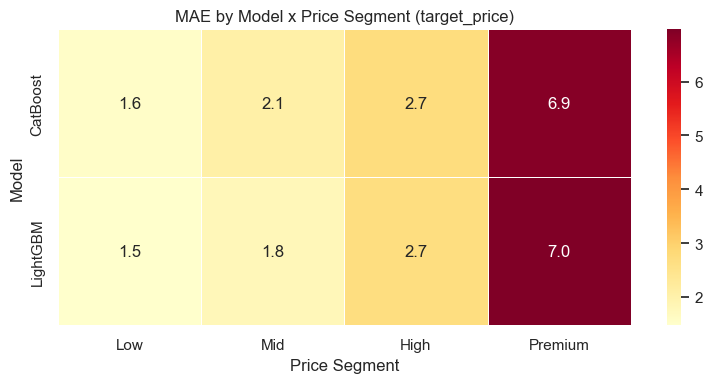

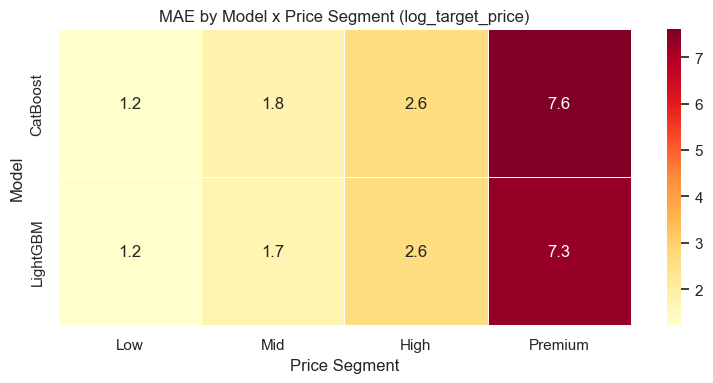

In [66]:
# Segment MAE heatmap: model x segment
for target_used in ANALYZED_TARGETS:
    pivot_mae = seg_df[seg_df["target_used"] == target_used].pivot_table(index="model_name", columns="price_segment", values="mae").reindex(columns=["Low", "Mid", "High", "Premium"])
    if pivot_mae.empty:
        continue
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.heatmap(pivot_mae, annot=True, fmt=",.1f", cmap="YlOrRd", linewidths=0.5, ax=ax)
    ax.set_title(f"MAE by Model x Price Segment ({target_used})")
    ax.set_xlabel("Price Segment")
    ax.set_ylabel("Model")
    plt.tight_layout()
    plt.savefig(DIAGNOSTICS_DIR / f"mae_heatmap_{target_used}.png", dpi=150, bbox_inches="tight")
    plt.show()


### Interpretation - MAE Heatmap by Segment

The MAE heatmaps show that absolute error increases from Low to Premium segments for both models and both target transformations. This confirms that Premium listings are the main source of large absolute errors.

For the primary pair `LightGBM + target_price`, the heatmap should be read as the main segment diagnostic. The log-target and CatBoost rows remain useful to check whether target transformation or model family changes the segment-level error profile.

The next notebook should tune `LightGBM + target_price` first, while retaining the comparison against `LightGBM + log_target_price` and CatBoost variants after tuning.

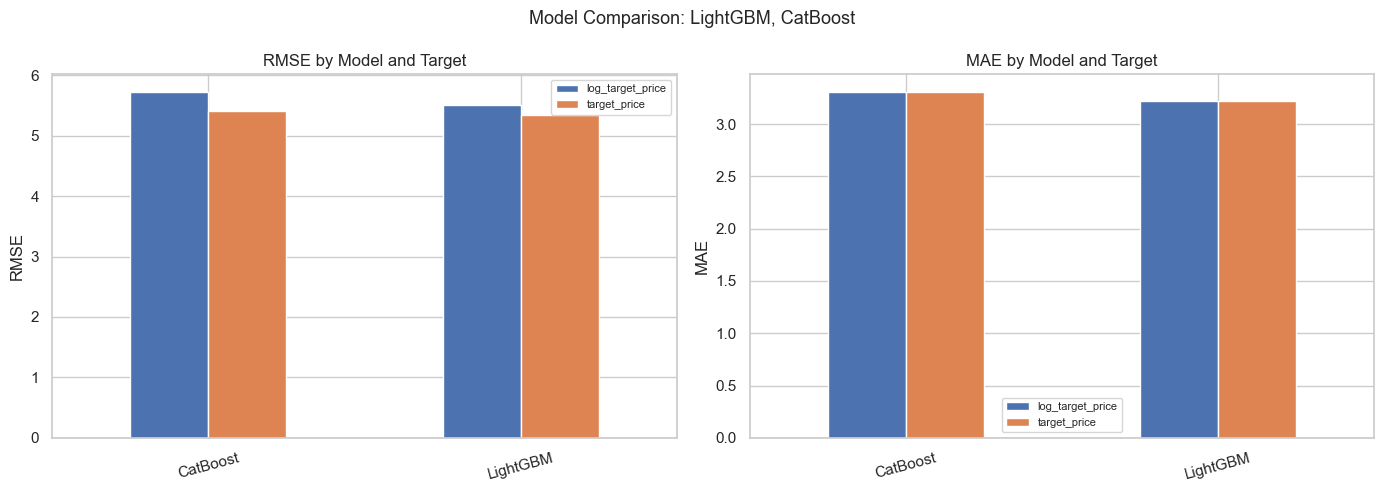

In [67]:
# Bar chart: RMSE and MAE by available model-target combinations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Model Comparison: {', '.join(SELECTED_MODELS)}", fontsize=13)
for ax, metric in zip(axes, ["rmse", "mae"]):
    pivot = summary_df.pivot_table(index="model_name", columns="target_used", values=metric)
    pivot.plot(kind="bar", ax=ax, title=f"{metric.upper()} by Model and Target")
    ax.set_xlabel("")
    ax.set_ylabel(metric.upper())
    ax.tick_params(axis="x", rotation=15)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(DIAGNOSTICS_DIR / "model_comparison_bar.png", dpi=150, bbox_inches="tight")
plt.show()


### Interpretation - Model Comparison

The model comparison is not used to automatically select the lowest-MAE row. Notebook 09 selected `numeric + LightGBM + target_price` as the balanced primary candidate, so notebook 10 uses that pair for the main diagnostics.

`LightGBM + log_target_price` remains an MAE/MAPE alternative. `CatBoost + target_price` remains a secondary boosting baseline. `CatBoost + log_target_price` remains a target-strategy check.

The next tuning notebook should start from `LightGBM + target_price`, then re-run the same comparison after tuning to verify whether the primary choice still holds under segment-aware validation.

## 14. Diagnostic Summary and Recommendations

Tổng hợp findings và recommended actions dựa trên diagnostics ở trên.


In [68]:
# Auto-generate ranking by available target
rankings = {}
for target_used in ANALYZED_TARGETS:
    ranked = summary_df[summary_df["target_used"] == target_used].sort_values("rmse").reset_index(drop=True)
    rankings[target_used] = ranked
    print(f"=== Ranking by RMSE ({target_used}) ===")
    for i, row in ranked.iterrows():
        print(f"  #{i+1}: {row['model_name']}  RMSE={row['rmse']:,.4f}  MAE={row['mae']:,.4f}  MAPE={row['mape']:.1%}")
    print()


=== Ranking by RMSE (target_price) ===
  #1: LightGBM  RMSE=5.3365  MAE=3.2246  MAPE=27.3%
  #2: CatBoost  RMSE=5.4136  MAE=3.3104  MAPE=29.1%

=== Ranking by RMSE (log_target_price) ===
  #1: LightGBM  RMSE=5.5069  MAE=3.2178  MAPE=25.2%
  #2: CatBoost  RMSE=5.7275  MAE=3.3062  MAPE=25.4%



In [69]:
analyzed_pairs_text = format_model_target_pairs(available_model_targets)
skipped_text = "; ".join(
    f"{m}+{t} missing {col}" for m, t, col in skipped_model_targets
) or "None"

recommendation_text = f"""
=============================================================
MODEL DIAGNOSTICS RECOMMENDATIONS
Notebook: 10_model_diagnostics_and_error_analysis.ipynb
Dataset : {PRIMARY_FEATURE_REPRESENTATION} features only (laptop_processed_numeric.csv)
Primary : {PRIMARY_FEATURE_REPRESENTATION} + {PRIMARY_MODEL} + {PRIMARY_TARGET}
Analyzed: {analyzed_pairs_text}
Skipped : {skipped_text}
=============================================================

FINAL DIAGNOSTIC SUMMARY
------------------------
Notebook này thực hiện diagnostic chính cho cấu hình numeric + LightGBM + target_price,
là candidate chính được chọn từ notebook 09. Kết quả phân tích lỗi cho thấy mô hình
hoạt động tốt ở vùng giá thấp và trung bình, nhưng sai số tăng ở vùng giá cao hoặc
các cấu hình hiếm.

Các candidate phụ gồm LightGBM + log_target_price, CatBoost + target_price và
CatBoost + log_target_price vẫn nên được giữ lại để so sánh sau tuning. Tuy nhiên,
hướng tuning chính ở notebook tiếp theo nên bắt đầu từ LightGBM + target_price.

CONFIRMED FINDINGS
------------------
1. Overall model comparison:
   LightGBM + target_price is the primary diagnostic pair. MAE remains close to the
   best alternative, while direct training on target_price keeps RMSE, R2, and residual
   interpretation aligned with the real-price scale.

2. Heteroscedasticity:
   Residual plots, binned residual summaries, and Spearman correlation tests show that
   error magnitude increases with actual price. Global metrics alone do not fully
   describe model quality across the price range.

3. Premium segment underprediction:
   Premium listings are often underpredicted. Prediction ratios and underprediction
   rates should be tracked explicitly during tuning.

4. Low-price overprediction:
   Low-price listings can be overpredicted. MAPE is inflated because actual prices are
   small, so Low-segment diagnostics should pair MAPE with absolute-error metrics.

5. Log-target trade-off:
   log_target_price can improve relative-error behavior, but it may compress high-price
   predictions more strongly. It remains a comparison candidate, not the primary
   diagnostic direction.

6. Potential error outliers:
   The flagged cases are potential model-error outliers, not necessarily invalid data.
   Review original features before excluding observations.

7. Exploratory corrections:
   Segment-level corrections are test-set optimistic and should not be reported as
   final performance unless validated out of sample.

RECOMMENDATIONS FOR NEXT TUNING NOTEBOOK
----------------------------------------
1. Tune LightGBM + target_price first.

2. Track residual behavior by price_range, brand, CPU tier, GPU tier/type, condition,
   and warranty when those fields are available.

3. Use cross-validation or a held-out validation split, and evaluate all metrics on the
   original price scale.

4. Track metrics at three levels:
   - Overall metrics: MAE, RMSE, R2, MAPE, median absolute error, severe error rate,
     extreme error rate.
   - Low segment metrics: MAPE, overprediction rate, prediction ratio.
   - Premium segment metrics: MAE, RMSE, underprediction rate, prediction ratio.

5. Compare again with LightGBM + log_target_price, CatBoost + target_price, and
   CatBoost + log_target_price after tuning.
"""
print(recommendation_text)

rec_path = DIAGNOSTICS_DIR / f"{output_prefix}_diagnostic_summary.txt"
rec_path.write_text(recommendation_text.strip(), encoding="utf-8")
print(f"\nSaved: {rec_path}")


MODEL DIAGNOSTICS RECOMMENDATIONS
Notebook: 10_model_diagnostics_and_error_analysis.ipynb
Dataset : numeric features only (laptop_processed_numeric.csv)
Primary : numeric + LightGBM + target_price
Analyzed: LightGBM + target_price, LightGBM + log_target_price, CatBoost + target_price, CatBoost + log_target_price
Skipped : None

FINAL DIAGNOSTIC SUMMARY
------------------------
Notebook này thực hiện diagnostic chính cho cấu hình numeric + LightGBM + target_price,
là candidate chính được chọn từ notebook 09. Kết quả phân tích lỗi cho thấy mô hình
hoạt động tốt ở vùng giá thấp và trung bình, nhưng sai số tăng ở vùng giá cao hoặc
các cấu hình hiếm.

Các candidate phụ gồm LightGBM + log_target_price, CatBoost + target_price và
CatBoost + log_target_price vẫn nên được giữ lại để so sánh sau tuning. Tuy nhiên,
hướng tuning chính ở notebook tiếp theo nên bắt đầu từ LightGBM + target_price.

CONFIRMED FINDINGS
------------------
1. Overall model comparison:
   LightGBM + target_price is the p

In [70]:
# Final diagnostic summary table and output file summary
primary_overall = summary_df[
    (summary_df["model_name"] == PRIMARY_MODEL) & (summary_df["target_used"] == PRIMARY_TARGET)
].iloc[0]
primary_seg = seg_df[(seg_df["model_name"] == PRIMARY_MODEL) & (seg_df["target_used"] == PRIMARY_TARGET)].set_index("price_segment")
premium_row = primary_seg.loc["Premium"] if "Premium" in primary_seg.index else None
low_row = primary_seg.loc["Low"] if "Low" in primary_seg.index else None
hetero_row = hetero_evidence_df[hetero_evidence_df["model_name"] == PRIMARY_MODEL].iloc[0] if not hetero_evidence_df.empty and PRIMARY_MODEL in hetero_evidence_df["model_name"].values else None
outlier_files = sorted(DIAGNOSTICS_DIR.glob(f"{output_prefix}*outlier*.csv")) + sorted(DIAGNOSTICS_DIR.glob("potential_outliers_*.csv"))
correction_files = sorted(DIAGNOSTICS_DIR.glob("correction_experiment_*.csv"))

final_diagnostic_summary = pd.DataFrame([
    {"Diagnostic Area": "Primary candidate", "Main Finding": f"Primary diagnostic pair is {PRIMARY_FEATURE_REPRESENTATION} + {PRIMARY_MODEL} + {PRIMARY_TARGET}.", "Evidence": f"MAE={primary_overall['mae']:,.2f}; RMSE={primary_overall['rmse']:,.2f}; R2={primary_overall['r2']:,.3f}", "Risk": "Global metrics can hide segment bias.", "Recommended Next Action": "Tune LightGBM + target_price first with segment-aware validation."},
    {"Diagnostic Area": "Candidate comparison", "Main Finding": "LightGBM/log-target and CatBoost variants are retained as secondary benchmarks.", "Evidence": "See strong_candidate_comparison.csv.", "Risk": "A tiny MAE gap can cause over-selection of log-target models if RMSE/R2/segment behavior is ignored.", "Recommended Next Action": "Compare all four candidate pairs again after tuning."},
    {"Diagnostic Area": "Segment bias", "Main Finding": "Bias varies by price segment for the primary diagnostic pair.", "Evidence": "See price_segment_bias_summary.csv and price_segment_bias_plots.png.", "Risk": "A globally strong model may fail in Low or Premium segments.", "Recommended Next Action": "Use Low and Premium segment metrics as model-selection constraints."},
    {"Diagnostic Area": "Premium underprediction", "Main Finding": "Premium segment shows underprediction if mean residual is positive and prediction ratio is below 1.", "Evidence": "n/a" if premium_row is None else f"mean_residual={premium_row['mean_residual']:,.2f}; underprediction_rate={premium_row['underprediction_rate']:.1%}; ratio={premium_row['prediction_ratio_mean']:.3f}", "Risk": "High-price misses can dominate RMSE and reduce trust in premium estimates.", "Recommended Next Action": "Test premium sample weighting and feature engineering for rare high-price configurations."},
    {"Diagnostic Area": "Low-price overprediction", "Main Finding": "Low segment shows overprediction if mean residual is negative and overprediction rate is high.", "Evidence": "n/a" if low_row is None else f"mean_residual={low_row['mean_residual']:,.2f}; overprediction_rate={low_row['overprediction_rate']:.1%}; ratio={low_row['prediction_ratio_mean']:.3f}", "Risk": "Low-price MAPE can become large even when absolute errors look modest.", "Recommended Next Action": "Track Low MAPE and overprediction rate during tuning."},
    {"Diagnostic Area": "Heteroscedasticity", "Main Finding": "Error magnitude may change with actual price.", "Evidence": "n/a" if hetero_row is None else f"Spearman rho={hetero_row['rho_abs_error']:.3f}; p={hetero_row['p_value']:.4f}; flag={hetero_row['heteroscedasticity_flag']}", "Risk": "RMSE may overweight expensive laptops and understate low-price relative error.", "Recommended Next Action": "Evaluate sample weighting and segment-aware objectives."},
    {"Diagnostic Area": "Log-target compression", "Main Finding": "Log-target compression is assessed only as a secondary target-strategy check.", "Evidence": "See *_log_vs_raw_compression.csv and log_vs_raw_compression_plot.png when generated.", "Risk": "Log target may reduce MAE/MAPE while compressing premium predictions.", "Recommended Next Action": "Keep log_target_price for comparison after tuning, not as the primary diagnostic pair."},
    {"Diagnostic Area": "Potential outliers", "Main Finding": "Extreme errors and prediction ratios were flagged for manual review.", "Evidence": f"Generated {len(outlier_files)} potential outlier or error-case CSV files.", "Risk": "Unverified data issues can distort tuning decisions.", "Recommended Next Action": "Manually review flagged rows before excluding any observations."},
    {"Diagnostic Area": "Correction experiments", "Main Finding": "Segment corrections are exploratory and test-set optimistic.", "Evidence": f"Generated {len(correction_files)} correction experiment CSV files.", "Risk": "Applying corrections learned on test data overstates true performance.", "Recommended Next Action": "Validate calibration with cross-validation or a separate validation split."},
])
summary_path = DIAGNOSTICS_DIR / f"{output_prefix}_final_diagnostic_summary.csv"
final_diagnostic_summary.to_csv(summary_path, index=False)
display(final_diagnostic_summary)
print("=== Output Files Saved ===")
for f in sorted(DIAGNOSTICS_DIR.iterdir()):
    exists = f.exists()
    size_kb = f.stat().st_size / 1024 if exists else 0
    print(f"  {f} | exists={exists} | size={size_kb:,.1f} KB")

,Diagnostic Area,Main Finding,Evidence,Risk,Recommended Next Action
0,Primary candidate,Primary diagnostic pair is numeric + LightGBM ...,MAE=3.22; RMSE=5.34; R2=0.893,Global metrics can hide segment bias.,Tune LightGBM + target_price first with segmen...
1,Candidate comparison,LightGBM/log-target and CatBoost variants are ...,See strong_candidate_comparison.csv.,A tiny MAE gap can cause over-selection of log...,Compare all four candidate pairs again after t...
2,Segment bias,Bias varies by price segment for the primary d...,See price_segment_bias_summary.csv and price_s...,A globally strong model may fail in Low or Pre...,Use Low and Premium segment metrics as model-s...
3,Premium underprediction,Premium segment shows underprediction if mean ...,mean_residual=2.71; underprediction_rate=61.9%...,High-price misses can dominate RMSE and reduce...,Test premium sample weighting and feature engi...
4,Low-price overprediction,Low segment shows overprediction if mean resid...,mean_residual=-1.05; overprediction_rate=73.0%...,Low-price MAPE can become large even when abso...,Track Low MAPE and overprediction rate during ...
5,Heteroscedasticity,Error magnitude may change with actual price.,Spearman rho=0.499; p=0.0000; flag=True,RMSE may overweight expensive laptops and unde...,Evaluate sample weighting and segment-aware ob...
6,Log-target compression,Log-target compression is assessed only as a s...,See *_log_vs_raw_compression.csv and log_vs_ra...,Log target may reduce MAE/MAPE while compressi...,Keep log_target_price for comparison after tun...
7,Potential outliers,Extreme errors and prediction ratios were flag...,Generated 2 potential outlier or error-case CS...,Unverified data issues can distort tuning deci...,Manually review flagged rows before excluding ...
8,Correction experiments,Segment corrections are exploratory and test-s...,Generated 2 correction experiment CSV files.,Applying corrections learned on test data over...,Validate calibration with cross-validation or ...


=== Output Files Saved ===
  Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\model_diagnostics\CatBoost_log_vs_raw_compression.csv | exists=True | size=0.6 KB
  Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\model_diagnostics\correction_experiment_CatBoost.csv | exists=True | size=0.9 KB
  Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\model_diagnostics\correction_experiment_LightGBM.csv | exists=True | size=0.9 KB
  Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\model_diagnostics\diagnostic_errors_long.csv | exists=True | size=991.0 KB
  Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\model_diagnostics\diagnostic_model_error_summary.csv | exists=True | size=1.3 KB
  Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\model_diagnostics\final_diagnostic_summary.csv | exists=True | size=2.2 KB
  Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\model_diagnostics\heteroscedasticity_binned_error_summary